# Fresh EC Balance Model - 24h

Self-contained EC-only notebook using the same 26h skip-holdout / walk-forward protocol as `Continuous_Rootzone_V8_24h.ipynb`.

This version enforces a 25-feature cap. It replaces two V8 EC features (`rad_morning`, `salt_concentration_pressure_t1`) with one stronger balance term: `ec0_x_p48_salt`.


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Loading & Helper Functions
# ==========================================
df = pd.read_csv('master.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')
master_df = df.copy().sort_index()

n_ph = int(master_df['ph'].notna().sum()) if 'ph' in master_df.columns else 0
n_ec = int(master_df['ec_ms'].notna().sum()) if 'ec_ms' in master_df.columns else 0
n_both = int((master_df['ph'].notna() & master_df['ec_ms'].notna()).sum()) if {'ph','ec_ms'}.issubset(master_df.columns) else 0

print(f'Loaded: {len(df)} rows')
print(f'Labeled samples -> pH: {n_ph}, EC: {n_ec}, both: {n_both}')

ACID_FERTS = ['Phosphoric acid[mg]-H3PO4']
SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
              'Kortin [mg]', 'Ammonium Nitrate [mg] -NH4NO3', 'Gypsum - CaSO4*2H2O [mg]']
CORE_SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
                   'Ammonium Nitrate [mg] -NH4NO3']
EC_COMPONENT_COLS = {
    'salt_kh2po4': 'Monopotassium Phosphate[mg] -KH2PO4',
    'salt_kcl': 'Potassium Chloride[mg] - KCL',
    'salt_kortin': 'Kortin [mg]',
    'salt_nh4no3': 'Ammonium Nitrate [mg] -NH4NO3',
    'salt_gypsum': 'Gypsum - CaSO4*2H2O [mg]',
}

def _to_num(s, d=0.0): return pd.to_numeric(s, errors='coerce').fillna(d)

def _sum_avail(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return float(fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sum()) if u else 0.0

def _sum_avail_series(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1) if u else pd.Series(0.0, index=fr.index)

def _get_fert_any(fr):
    if 'fertilization_flag' in fr.columns: return _to_num(fr['fertilization_flag'])
    a = 'fertilization_type_a_flag' in fr.columns
    b = 'fertilization_type_b_flag' in fr.columns
    if a or b:
        fa = _to_num(fr['fertilization_type_a_flag']) if a else pd.Series(0., index=fr.index)
        fb = _to_num(fr['fertilization_type_b_flag']) if b else pd.Series(0., index=fr.index)
        return ((fa > 0) | (fb > 0)).astype(float)
    return pd.Series(0., index=fr.index)


Loaded: 16682 rows
Labeled samples -> pH: 109, EC: 109, both: 109


In [2]:
# ==========================================
# 2. Feature Extraction
# ==========================================
def get_features_for_row(master_df, anchor_idx, current_idx):
    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    ph0 = float(master_df.loc[t0, 'ph'])
    ec0 = float(master_df.loc[t0, 'ec_ms'])
    gap_h = float((t1 - t0).total_seconds() / 3600.0)
    safe_gap_h = max(gap_h, 0.16)

    # Strictly use [t0, t1) to avoid peeking at sample-time events
    seg = master_df.loc[(master_df.index >= t0) & (master_df.index < t1)]

    # Absolute sums
    fert_acid_total = _sum_avail(seg, ACID_FERTS)
    fert_salt_total = _sum_avail(seg, SALT_FERTS)
    fert_total = fert_acid_total + fert_salt_total
    irr_total = float(_to_num(seg['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in seg.columns else 0.0

    # Time-weighted sums (recency-aware)
    fert_acid_s = _sum_avail_series(seg, ACID_FERTS)
    fert_salt_s = _sum_avail_series(seg, SALT_FERTS)
    fert_total_s = fert_acid_s + fert_salt_s
    irr_s = _to_num(seg['irrigation_ml_current']) if 'irrigation_ml_current' in seg.columns else pd.Series(0.0, index=seg.index)

    time_to_t1_hours = (t1 - seg.index).total_seconds() / 3600.0 if len(seg) else np.array([])
    decay_lambda = 0.34
    weights = np.exp(-decay_lambda * time_to_t1_hours) if len(seg) else np.array([])

    weighted_irr = float((irr_s * weights).sum()) if len(seg) else 0.0
    weighted_fert_acid = float((fert_acid_s * weights).sum()) if len(seg) else 0.0
    weighted_fert_salt = float((fert_salt_s * weights).sum()) if len(seg) else 0.0
    weighted_total_fert = float((fert_total_s * weights).sum()) if len(seg) else 0.0

    # Core drivers
    # fert_conc: +1 denominator keeps values stable when irr_total==0
    fert_conc = float(fert_total / (irr_total + 1.0))
    # fert_concentration used to divide by (irr_total + 1e-6), producing values
    # up to ~1e6 when irr_total==0 — extreme outliers that dominated tree splits.
    # Unified to the same +1 denominator as fert_conc, clipped as a safety net.
    fert_concentration = float(np.clip(fert_total / (irr_total + 1.0), 0, 1e4))
    salt_balance = float(fert_salt_total - irr_total)

    ET0_sum = float(_to_num(seg['ET0']).sum()) if 'ET0' in seg.columns else 0.0
    ET0_per_hour = float(ET0_sum / safe_gap_h)
    # leaching_fraction: clipped to [0, 100] — short gaps with near-zero ET0
    # produced astronomically large values that dominated tree splits.
    leaching_fraction = float(np.clip(irr_total / (ET0_sum + 1e-3), 0, 100))

    log_ec_drive = float(np.log(fert_conc + 0.01) - np.log(ec0 + 0.01))
    ph_drive = float(fert_total / (ph0 + 1e-3))

    # pH-specific features
    # h3po4_total: direct phosphoric acid dose in window
    H3PO4_COL = 'Phosphoric acid[mg]-H3PO4'
    h3po4_total = float(_to_num(seg[H3PO4_COL]).sum()) if H3PO4_COL in seg.columns else 0.0
    # acid_rate: phosphoric acid applied per hour — separates a large dose
    # over a long gap from a concentrated burst, which matters for pH drop.
    acid_rate = float(fert_acid_total / safe_gap_h)
    # ph_buffer_ratio: acid load relative to ionic strength (ec0). Higher EC
    # means more ions in solution = more buffering = same acid moves pH less.
    ph_buffer_ratio = float(fert_acid_total / (ec0 + 0.1))
    # soil_temp_sq: respiration rate roughly doubles per 10°C (Q10 rule),
    # so a quadratic term captures the nonlinear CO2 production effect on pH.
    soil_temp_sq = float(_to_num(seg['soil_temp_pred']).mean() ** 2) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0

    # Climate dynamics
    if 'internal_air_temp_c' in seg.columns and 'internal_rh_%' in seg.columns and len(seg) > 0:
        ts = _to_num(seg['internal_air_temp_c'])
        rhs = _to_num(seg['internal_rh_%'])
        ess = 0.6108 * np.exp((17.27 * ts) / (ts + 237.3))
        vpds = ess * (1. - rhs / 100.)
        vpd_mean = float(vpds.mean())
    else:
        vpd_mean = 0.0

    soil_temp_mean = float(_to_num(seg['soil_temp_pred']).mean()) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0
    canopy = float(_to_num(seg['canopy_cover']).mean()) if 'canopy_cover' in seg.columns and len(seg) > 0 else 0.0
    transpiration_pull = float(vpd_mean * canopy)
    evapo_concentration = float(ET0_sum * canopy)

    temp_s = _to_num(seg['internal_air_temp_c']) if 'internal_air_temp_c' in seg.columns else pd.Series(dtype=float)
    if len(temp_s) > 1:
        temp_trend = float(temp_s.iloc[-1] - temp_s.iloc[0])
        temp_range = float(temp_s.max() - temp_s.min())
    else:
        temp_trend = 0.0
        temp_range = 0.0

    rad_s = _to_num(seg['internal_radiation']) if 'internal_radiation' in seg.columns else pd.Series(dtype=float)
    rad_max = float(rad_s.max()) if len(rad_s) > 0 else 0.0
    daylight_proportion = float((rad_s > 10).sum() / 6.0 / safe_gap_h) if len(rad_s) > 0 else 0.0

    # Interaction features (batch 1) — placed here so vpd_mean, soil_temp_mean,
    # and rad_s are all already defined.
    # rad_integral: cumulative light energy (Wh/m²) — plants integrate radiation
    # over the full window, not just whether it was daytime.
    rad_integral = float(rad_s.sum() * (10.0 / 60.0)) if len(rad_s) > 0 else 0.0
    # ph_deviation: distance from agronomic optimum (6.5) — encodes the
    # operator mean-reversion pressure that ph0 alone cannot capture.
    ph_deviation = float(ph0 - 6.5)
    # photo_temp_interaction: vpd_mean × soil_temp_mean — coupled biochemical
    # CO2 uptake rate; neither driver predicts pH change independently.
    photo_temp_interaction = float(vpd_mean * soil_temp_mean)

    # Hours since events
    if 'irrigation_ml_current' in seg.columns and len(seg) > 0:
        ie = _to_num(seg['irrigation_ml_current'])
        ii = ie[ie > 0].index
        hrs_since_irr = float((t1 - ii.max()).total_seconds() / 3600.) if len(ii) > 0 else gap_h
    else:
        hrs_since_irr = gap_h

    fser = _get_fert_any(seg) if len(seg) > 0 else pd.Series(dtype=float)
    fi2 = fser[fser > 0].index
    hrs_since_fert = float((t1 - fi2.max()).total_seconds() / 3600.) if len(fi2) > 0 else gap_h

    # Interaction features (batch 2) — placed here so hrs_since_irr is defined.
    # acid_dilution: acid / (irr + fert + 1) — actual acid concentration in
    # the liquid applied; neither term alone captures dilution by irrigation.
    acid_dilution = float(fert_acid_total / (irr_total + fert_total + 1.0))
    # buffered_acid_pressure: recency-weighted acid concentration scaled by
    # irrigation dilution and EC buffering.
    buffered_acid_pressure = float(weighted_fert_acid / ((weighted_irr + 1.0) * (ec0 + 0.1)))
    # canopy_et0: canopy × ET0_sum — actual photosynthetic demand met by crop;
    # small canopy at high ET0 has minimal CO2 uptake and pH effect.
    canopy_et0 = float(canopy * ET0_sum)
    # salt_stress_index: hrs_since_irr × ec0 — salt concentration builds up
    # when irrigation is withheld; high EC × long gap = stronger buffering.
    salt_stress_index = float(hrs_since_irr * ec0)

    # Interaction features (batch 3)
    # rad_x_canopy: mean radiation x canopy = actual light intercepted by leaves,
    # the direct driver of photosynthesis and CO2 uptake (r=0.51 with dph).
    rad_x_canopy = float(rad_s.mean() * canopy) if len(rad_s) > 0 else 0.0
    # temp_x_canopy: soil_temp x canopy = root mass x temperature drives root
    # respiration CO2 production which acidifies the rootzone.
    temp_x_canopy = float(soil_temp_mean * canopy)

    # Time-of-day (diurnal cycles)
    hour_a = t0.hour + t0.minute / 60.0
    hour_b = t1.hour + t1.minute / 60.0

    component_totals = {
        key: float(_to_num(seg[col]).sum()) if col in seg.columns else 0.0
        for key, col in EC_COMPONENT_COLS.items()
    }
    salt_conc_t0_t1 = float(fert_salt_total / (irr_total + 1.0))
    acid_conc_t0_t1 = float(fert_acid_total / (irr_total + 1.0))
    weighted_salt_conc = float(weighted_fert_salt / (weighted_irr + 1.0))
    weighted_total_conc = float(weighted_total_fert / (weighted_irr + 1.0))
    salt_per_hour = float(fert_salt_total / safe_gap_h)
    irr_per_hour = float(irr_total / safe_gap_h)
    salt_to_et0 = float(fert_salt_total / (ET0_sum + 0.1))
    irr_to_et0 = float(irr_total / (ET0_sum + 0.1))
    overnight_fraction = float((_to_num(seg['internal_radiation']) <= 10).sum() / 6.0 / safe_gap_h) \
        if len(seg) > 0 and 'internal_radiation' in seg.columns else 0.0
    salt_x_daylight = float(fert_salt_total * daylight_proportion)
    days_after_planting_t0 = float(master_df.loc[t0, 'days_after_planting']) \
        if 'days_after_planting' in master_df.columns else 0.0
    days_after_planting_t1 = float(master_df.loc[t1, 'days_after_planting']) \
        if 'days_after_planting' in master_df.columns else days_after_planting_t0
    canopy_t1 = float(master_df.loc[t1, 'canopy_cover']) if 'canopy_cover' in master_df.columns else canopy
    stage_x_salt_conc = float((days_after_planting_t1 / 100.0) * salt_conc_t0_t1)
    ec_regime_low = float(ec0 <= 0.5)
    ec_regime_mid = float((ec0 > 0.5) and (ec0 <= 1.5))
    ec_regime_high = float((ec0 > 1.5) and (ec0 <= 3.0))
    ec_regime_very_high = float(ec0 > 3.0)
    fertigation_event = float(fert_salt_total > 0)
    low_dilution_event = float(irr_total <= 300.0)
    salt_shock_event = float((fert_salt_total >= 325.0) and (irr_total <= 300.0))
    super_shock_event = float((fert_salt_total >= 900.0) and (irr_total <= 400.0))
    ec_gap_interaction = float(ec0 * gap_h)
    ec_log_anchor = float(np.log(ec0 + 0.05))
    recent_6h = seg.loc[seg.index >= t1 - pd.Timedelta(hours=6)] if len(seg) > 0 else seg
    salt_recent_6h = float(_sum_avail(recent_6h, SALT_FERTS)) if len(recent_6h) > 0 else 0.0
    core_salt_s = _sum_avail_series(seg, CORE_SALT_FERTS) if len(seg) > 0 else pd.Series(0.0, index=seg.index)
    salt_event_idx = core_salt_s[core_salt_s > 0].index.max() if len(core_salt_s[core_salt_s > 0]) else None
    irr_event_idx = irr_s[irr_s > 0].index.max() if len(irr_s[irr_s > 0]) else None
    last_salt_dose = float(core_salt_s.loc[salt_event_idx]) if salt_event_idx is not None else 0.0
    last_irr_amount = float(irr_s.loc[salt_event_idx]) if salt_event_idx is not None and salt_event_idx in irr_s.index else 0.0
    hrs_since_last_salt_event = float((t1 - salt_event_idx).total_seconds() / 3600.0) if salt_event_idx is not None else gap_h
    last_event_salt_conc = float(last_salt_dose / (last_irr_amount + 1.0))
    irr_after_last_salt = float(_to_num(seg.loc[seg.index > salt_event_idx, 'irrigation_ml_current']).sum()) \
        if salt_event_idx is not None and 'irrigation_ml_current' in seg.columns else 0.0

    return {
        'ph0': ph0,
        'ec0': ec0,
        'gap_hours': gap_h,

        # absolute totals
        'irr_total_t0_t1': irr_total,
        'fert_total_t0_t1': fert_total,
        'fert_salt_total_t0_t1': fert_salt_total,
        'salt_balance_t0_t1': salt_balance,
        'ET0_sum_t0_t1': ET0_sum,

        # weighted totals
        'weighted_irr': weighted_irr,
        'weighted_total_fert': weighted_total_fert,
        'weighted_fert_acid': weighted_fert_acid,
        'weighted_fert_salt': weighted_fert_salt,

        # driver terms
        'fert_conc': fert_conc,
        'fert_concentration': fert_concentration,
        'log_ec_drive': log_ec_drive,
        'ph_drive': ph_drive,
        'leaching_fraction': leaching_fraction,
        'ET0_per_hour': ET0_per_hour,

        # pH-specific
        'acid_rate': acid_rate,
        'ph_buffer_ratio': ph_buffer_ratio,
        'soil_temp_sq': soil_temp_sq,

        # interaction features (batch 1)
        'rad_integral': rad_integral,
        'ph_deviation': ph_deviation,
        'photo_temp_interaction': photo_temp_interaction,

        # interaction features (batch 2)
        'acid_dilution': acid_dilution,
        'buffered_acid_pressure': buffered_acid_pressure,
        'canopy_et0': canopy_et0,
        'salt_stress_index': salt_stress_index,

        # interaction features (batch 3)
        'rad_x_canopy': rad_x_canopy,
        'temp_x_canopy': temp_x_canopy,

        # climate
        'vpd_mean': vpd_mean,
        'soil_temp_mean': soil_temp_mean,
        'soil_temp_t0': soil_temp_mean,  # alias: soil temp at anchor point
        'canopy': canopy,
        'transpiration_pull': transpiration_pull,
        'evapo_concentration': evapo_concentration,

        # fertilization chemistry
        'h3po4_total': h3po4_total,
        **component_totals,
        'salt_conc_t0_t1': salt_conc_t0_t1,
        'acid_conc_t0_t1': acid_conc_t0_t1,
        'weighted_salt_conc': weighted_salt_conc,
        'weighted_total_conc': weighted_total_conc,
        'salt_per_hour': salt_per_hour,
        'irr_per_hour': irr_per_hour,
        'salt_to_et0': salt_to_et0,
        'irr_to_et0': irr_to_et0,
        'salt_x_daylight': salt_x_daylight,
        'overnight_fraction': overnight_fraction,
        'days_after_planting_t0': days_after_planting_t0,
        'days_after_planting_t1': days_after_planting_t1,
        'canopy_t1': canopy_t1,
        'stage_x_salt_conc': stage_x_salt_conc,
        'ec_regime_low': ec_regime_low,
        'ec_regime_mid': ec_regime_mid,
        'ec_regime_high': ec_regime_high,
        'ec_regime_very_high': ec_regime_very_high,
        'fertigation_event': fertigation_event,
        'low_dilution_event': low_dilution_event,
        'salt_shock_event': salt_shock_event,
        'super_shock_event': super_shock_event,
        'ec_gap_interaction': ec_gap_interaction,
        'ec_log_anchor': ec_log_anchor,
        # recency / dynamics
        'hrs_since_irr': hrs_since_irr,
        'hrs_since_fert': hrs_since_fert,
        'temp_trend': temp_trend,
        'temp_range': temp_range,
        'rad_max': rad_max,
        'daylight_proportion': daylight_proportion,
        'salt_recent_6h': salt_recent_6h,
        'hrs_since_last_salt_event': hrs_since_last_salt_event,
        'irr_after_last_salt': irr_after_last_salt,
        'last_event_salt_conc': last_event_salt_conc,

        # diurnal
        'hour_sin_a': float(np.sin(2 * np.pi * hour_a / 24)),
        'hour_cos_a': float(np.cos(2 * np.pi * hour_a / 24)),
        'hour_sin_b': float(np.sin(2 * np.pi * hour_b / 24)),
        'hour_cos_b': float(np.cos(2 * np.pi * hour_b / 24)),

        # V6 morning-flag features
        # t0_morning: anchor is a morning reading (pH at daily minimum).
        # r=+0.581 with ΔpH on gap>6h. Targets morning-to-morning 24h failure mode.
        't0_morning': int(5 <= t0.hour <= 10),
        # t1_morning: target is a morning reading (pH at daily minimum).
        # r=−0.557 with ΔpH on gap>6h.
        't1_morning': int(5 <= t1.hour <= 10),

        # soil_delta: soil temperature change t0→t1.
        # r=+0.604 with ΔpH — strongest new feature found.
        # Warming rootzone → rising pH; cooling → falling pH.
        'soil_delta': float(
            (_to_num(master_df.loc[t1:t1, 'soil_temp_pred']).iloc[0]
             if t1 in master_df.index and master_df.loc[t1, 'soil_temp_pred'] != 0
             else float(_to_num(seg['soil_temp_pred']).iloc[-1]) if len(seg) > 0 else 0.0)
            - float(_to_num(master_df.loc[t0:t0, 'soil_temp_pred']).iloc[0])
        ),
        # rad_t1_log: log(1 + radiation at measurement moment t1).
        # Low linear r but strong non-linear pattern — dark/dim/bright splits.
        'rad_t1_log': float(np.log1p(
            float(_to_num(master_df.loc[t1:t1, 'internal_radiation']).iloc[0])
            if t1 in master_df.index else 0.0
        )),
        # overnight_h: hours of darkness in window (radiation ≤ 10 W/m²).
        # CO2 accumulates during dark → pH drops. Captures overnight base shift.
        'overnight_h': float((_to_num(seg['internal_radiation']) <= 10).sum()) / 6.0
            if len(seg) > 0 else 0.0,
        # rad_morning: total radiation 06:00–12:00 within window.
        # Morning photosynthesis intensity → determines afternoon pH peak magnitude.
        'rad_morning': float(_to_num(
            seg.loc[(seg.index.hour >= 6) & (seg.index.hour < 12), 'internal_radiation']
        ).sum()) if len(seg) > 0 else 0.0,
    }


# ==========================================
# 2b. History Feature Extraction (24h before t1 — all anchored to t1)
# ==========================================
def get_history_features(master_df, t0, t1):
    """
    Extract 7 history features — all anchored to t1.

    All windows use t1 as the reference point, looking back up to 24h.
    No leakage: only operational events (irrigation/fertilization) are read,
    never pH or EC at t1.

    Irrigation sub-windows (anchored to t1):
      recent : [t1-6h,  t1)    — immediate dilution effect
      mid    : [t1-12h, t1-6h) — nitrification peak (8-16h lag)
      prior  : [t1-24h, t1-12h) — residual buffering / background

    Acid fertilization:
      hist_acid_decay — exponentially decayed sum over [t1-24h, t1)
      decay from t1: dose * exp(-λ * hrs_before_t1), λ=0.34/hr
      encodes both amount and recency in one feature.

    State features (anchored to t1, window [t1-24h, t1)):
      hist_salt_buildup   — net salt accumulation in the 24h before t1
      hist_hrs_since_fert — hours since last fertigation before t1
      hist_hrs_since_irr  — hours since last irrigation before t1
    """
    t0 = pd.Timestamp(t0)
    t1 = pd.Timestamp(t1)

    w_prior_start = t1 - pd.Timedelta(hours=24)

    def _get_seg(start, stop):
        """Rows in [start, stop)."""
        if start >= stop:
            return master_df.iloc[0:0]
        return master_df.loc[(master_df.index >= start) & (master_df.index < stop)]

    # ── Irrigation sub-windows: full [t1-Xh, t1) including t0→t1 ────────────
    seg_irr_recent = _get_seg(t1 - pd.Timedelta(hours=6),  t1)
    seg_irr_mid    = _get_seg(t1 - pd.Timedelta(hours=12), t1 - pd.Timedelta(hours=6))
    seg_irr_prior  = _get_seg(t1 - pd.Timedelta(hours=24), t1 - pd.Timedelta(hours=12))

    def _irr(seg):
        if 'irrigation_ml_current' not in seg.columns or len(seg) == 0:
            return 0.0
        return float(_to_num(seg['irrigation_ml_current']).sum())

    irr_recent = _irr(seg_irr_recent)
    irr_mid    = _irr(seg_irr_mid)
    irr_prior  = _irr(seg_irr_prior)
    hist_dark_recent_6h = (
        float((_to_num(seg_irr_recent['internal_radiation']) <= 10).sum()) / 6.0
        if 'internal_radiation' in seg_irr_recent.columns and len(seg_irr_recent) > 0
        else 0.0
    )

    # ── Salt ramp: full [t1-24h, t1) anchored to t1 ──────────────────────────
    # hist_salt_ramp = sum(dose_i * (1 - exp(-λ * hrs_before_t1)))
    # Salts accumulate and equilibrate — opposite of acid decay.
    # Recent dose (1h ago) gets low weight (not dissolved yet).
    # Old dose (20h ago) gets weight ~1.0 (fully equilibrated).
    seg_salt_full = _get_seg(w_prior_start, t1)
    DECAY_LAMBDA  = 0.34
    hist_salt_ramp = 0.0
    if len(seg_salt_full) > 0:
        salt_doses = _sum_avail_series(seg_salt_full, SALT_FERTS)
        nonzero_salt = salt_doses > 0
        if nonzero_salt.any():
            hrs_s = np.array((t1 - seg_salt_full.index[nonzero_salt]).total_seconds()) / 3600.0
            hist_salt_ramp = float((salt_doses[nonzero_salt].values *
                                    (1.0 - np.exp(-DECAY_LAMBDA * hrs_s))).sum())

    # ── Acid decay: full [t1-24h, t1) anchored to t1 ─────────────────────────
    # hist_acid_decay = sum(dose_i * exp(-λ * hrs_before_t1))
    # Events near t1 get high weight; events 24h before t1 get low weight.
    # λ=0.34/hr matches V3 recency decay constant.
    # Vectorized — avoids O(n²) slowdown during walk-forward retraining.
    seg_acid_full = _get_seg(w_prior_start, t1)
    DECAY_LAMBDA  = 0.34
    if len(seg_acid_full) > 0:
        acid_doses = _sum_avail_series(seg_acid_full, ACID_FERTS)
        nonzero_mask = acid_doses > 0
        if nonzero_mask.any():
            hrs_before_t1 = np.array((t1 - seg_acid_full.index[nonzero_mask]).total_seconds()) / 3600.0
            hist_acid_decay = float((acid_doses[nonzero_mask].values *
                                     np.exp(-DECAY_LAMBDA * hrs_before_t1)).sum())
        else:
            hist_acid_decay = 0.0
    else:
        hist_acid_decay = 0.0

    # ── State features: full 24h before t1, anchored to t1 ───────────────────
    seg_state = _get_seg(t1 - pd.Timedelta(hours=24), t1)

    if len(seg_state) > 1:
        hirr_s     = _to_num(seg_state['irrigation_ml_current']) if 'irrigation_ml_current' in seg_state.columns else pd.Series(0.0, index=seg_state.index)
        irr_s_sum  = float(hirr_s.sum())
        h_salt     = _sum_avail(seg_state, SALT_FERTS)
        hist24_salt_total = float(h_salt)
        # Exponentially decayed salt buildup (λ=0.15/hr, slower than acid):
        # weights recent salt events more than older ones — old Aug 17-18
        # fert events no longer dominate after 2 days of plain irrigation.
        _salt_s = _sum_avail_series(seg_state, SALT_FERTS)
        _nz_salt = _salt_s > 0
        if _nz_salt.any():
            _hrs_before_t1 = np.array((t1 - seg_state.index[_nz_salt]).total_seconds()) / 3600.0
            _decay = np.exp(-0.15 * _hrs_before_t1)
            _decayed_salt = float((_salt_s[_nz_salt].values * _decay).sum())
        else:
            _decayed_salt = 0.0
        hist_salt_buildup = float(_decayed_salt - irr_s_sum * 0.1)

        hfert      = _get_fert_any(seg_state)
        fert_times = seg_state.index[hfert > 0]
        hist_hrs_since_fert = float((t1 - fert_times[-1]).total_seconds() / 3600.) if len(fert_times) > 0 else 24.0

        hirr_times = seg_state.index[hirr_s > 0]
        hist_hrs_since_irr = float((t1 - hirr_times[-1]).total_seconds() / 3600.) if len(hirr_times) > 0 else 24.0
    else:
        hist24_salt_total   = 0.0
        hist_salt_buildup   = 0.0
        hist_hrs_since_fert = 24.0
        hist_hrs_since_irr  = 24.0

    return {
        # irrigation sub-windows anchored to t1 (full window including t0→t1)
        'hist_irr_recent':     irr_recent,
        'hist_irr_mid':        irr_mid,
        'hist_irr_prior':      irr_prior,
        'hist_dark_recent_6h': hist_dark_recent_6h,
        # salt ramp anchored to t1 (equilibration weighting, λ=0.34/hr)
        'hist_salt_ramp':      hist_salt_ramp,
        # acid decay anchored to t1 (amount × recency, λ=0.34/hr)
        'hist_acid_decay':     hist_acid_decay,
        # state features anchored to t0 (24h before window start)
        'hist24_salt_total':   hist24_salt_total,
        'hist_salt_buildup':   hist_salt_buildup,
        'hist_hrs_since_fert': hist_hrs_since_fert,
        'hist_hrs_since_irr':  hist_hrs_since_irr,
    }



def get_target_prevday_features(master_df, t1):
    """Operational carry-over from the previous day before t1.

    These features capture lingering irrigation and acid effects from
    the 24-48h period before the target time without leaking target chemistry.
    """
    t1 = pd.Timestamp(t1)
    start = t1 - pd.Timedelta(hours=48)
    stop = t1 - pd.Timedelta(hours=24)
    seg = master_df.loc[(master_df.index >= start) & (master_df.index < stop)]

    hist48_irr_prevday = (
        float(_to_num(seg['irrigation_ml_current']).sum())
        if 'irrigation_ml_current' in seg.columns and len(seg) > 0
        else 0.0
    )
    hist48_acid_prevday = float(_sum_avail(seg, ACID_FERTS)) if len(seg) > 0 else 0.0
    hist48_salt_prevday = float(_sum_avail(seg, SALT_FERTS)) if len(seg) > 0 else 0.0
    return {
        'hist48_irr_prevday': hist48_irr_prevday,
        'hist48_acid_prevday': hist48_acid_prevday,
        'hist48_salt_prevday': hist48_salt_prevday,
    }

JOINT_SENSOR_IDX = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
JOINT_SENSOR_POS = {ts: i for i, ts in enumerate(JOINT_SENSOR_IDX)}


def get_features_v6(master_df, anchor_idx, current_idx):
    """Combine window features + t1 history + previous-day target context."""
    window = get_features_for_row(master_df, anchor_idx, current_idx)
    history = get_history_features(master_df, t0=anchor_idx, t1=current_idx)
    prevday = get_target_prevday_features(master_df, t1=current_idx)
    feats = {**window, **history, **prevday}

    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    recent_2h = master_df.loc[(master_df.index >= t1 - pd.Timedelta(hours=2)) & (master_df.index < t1)]
    hist24 = master_df.loc[(master_df.index >= t0 - pd.Timedelta(hours=24)) & (master_df.index < t0)]
    hist48 = master_df.loc[(master_df.index >= t0 - pd.Timedelta(hours=48)) & (master_df.index < t0)]
    window_seg = master_df.loc[(master_df.index >= t0) & (master_df.index < t1)]
    if len(window_seg) > 0:
        air_s = _to_num(window_seg['internal_air_temp_c'])
        rh_s = _to_num(window_seg['internal_rh_%'])
        soil_s = _to_num(window_seg['soil_temp_pred'])
        temp_rh_balance = float((air_s / (rh_s + 1.0) * 100.0).mean())
        soil_air_balance = float(soil_s.mean() - air_s.mean())
    else:
        temp_rh_balance = 0.0
        soil_air_balance = 0.0

    salt_2h = float(_sum_avail(recent_2h, SALT_FERTS)) if len(recent_2h) > 0 else 0.0
    irr_2h = float(_to_num(recent_2h['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in recent_2h.columns and len(recent_2h) > 0 else 0.0
    salt24 = float(_sum_avail(hist24, SALT_FERTS)) if len(hist24) > 0 else 0.0
    irr24 = float(_to_num(hist24['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in hist24.columns and len(hist24) > 0 else 0.0
    salt48 = float(_sum_avail(hist48, SALT_FERTS)) if len(hist48) > 0 else 0.0
    irr48 = float(_to_num(hist48['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in hist48.columns and len(hist48) > 0 else 0.0

    hist_t1_24 = master_df.loc[(master_df.index >= t1 - pd.Timedelta(hours=24)) & (master_df.index < t1)]
    hist_core_t1 = _sum_avail_series(hist_t1_24, CORE_SALT_FERTS) if len(hist_t1_24) > 0 else pd.Series(dtype=float)
    hist_irr_t1 = _to_num(hist_t1_24['irrigation_ml_current']) if 'irrigation_ml_current' in hist_t1_24.columns else pd.Series(0.0, index=hist_t1_24.index)
    nz_hist_core = hist_core_t1[hist_core_t1 > 0]
    if len(nz_hist_core) > 0:
        major_idx = nz_hist_core.index.max()
        major_dose = float(hist_core_t1.loc[major_idx])
        major_irr = float(hist_irr_t1.loc[major_idx]) if major_idx in hist_irr_t1.index else 0.0
        after_major = hist_t1_24.loc[hist_t1_24.index >= major_idx]
        rad_after_major = float(_to_num(after_major['internal_radiation']).sum()) if 'internal_radiation' in after_major.columns else 0.0
        et0_after_major = float(_to_num(after_major['ET0']).sum()) if 'ET0' in after_major.columns else 0.0
        hist_major_last_event_salt_conc_t1 = float(major_dose / (major_irr + 1.0))
        hist_hrs_since_major_salt_t1 = float((t1 - major_idx).total_seconds() / 3600.0)
        hist_plain_after_major_salt_t1 = float(hist_irr_t1.loc[hist_irr_t1.index > major_idx].sum())
        hist_major_salt_light_balance = float(
            hist_major_last_event_salt_conc_t1 * np.log1p(rad_after_major) / (hist_plain_after_major_salt_t1 + 1.0)
        )
        salt_concentration_pressure_t1 = float(
            hist_major_last_event_salt_conc_t1 * et0_after_major / (hist_plain_after_major_salt_t1 + 1.0)
        )
    else:
        hist_major_last_event_salt_conc_t1 = 0.0
        hist_hrs_since_major_salt_t1 = 24.0
        hist_plain_after_major_salt_t1 = 0.0
        hist_major_salt_light_balance = 0.0
        salt_concentration_pressure_t1 = 0.0

    pos = JOINT_SENSOR_POS.get(t0)
    prev_ec_delta = 0.0
    prev_ec_slope = 0.0
    prev_gap_h = feats['gap_hours']
    ec_trend_48h = 0.0
    if pos is not None and pos >= 1:
        t_prev = pd.Timestamp(JOINT_SENSOR_IDX[pos - 1])
        prev_ec = float(master_df.loc[t_prev, 'ec_ms'])
        prev_gap_h = max((t0 - t_prev).total_seconds() / 3600.0, 1e-6)
        prev_ec_delta = float(feats['ec0'] - prev_ec)
        prev_ec_slope = float(prev_ec_delta / prev_gap_h)
        # ec_trend_48h: slope over the last 2 labeled intervals (t_prev2 → t0).
        # Captures sustained EC decline that single-step prev_ec_slope misses.
        # e.g. after a fert peak, 2+ consecutive plain-irrigation drops.
        if pos >= 2:
            t_prev2 = pd.Timestamp(JOINT_SENSOR_IDX[pos - 2])
            ec_prev2 = float(master_df.loc[t_prev2, 'ec_ms'])
            gap_2step = max((t0 - t_prev2).total_seconds() / 3600.0, 1e-6)
            ec_trend_48h = float((feats['ec0'] - ec_prev2) / gap_2step)
        else:
            ec_trend_48h = prev_ec_slope

    gap_h_safe = max(float(feats['gap_hours']), 0.25)
    feats.update({
        'recent_salt_conc_2h': float(salt_2h / (irr_2h + 1.0)),
        'hist24_net_salt': float(salt24 - 0.25 * irr24),
        'hist48_net_salt': float(salt48 - 0.18 * irr48),
        'prev_ec_delta': prev_ec_delta,
        'prev_ec_slope': prev_ec_slope,
        'prev_gap_h': prev_gap_h,
        # ec_trend_48h: 2-step EC momentum — negative = sustained EC decline.
        'ec_trend_48h': ec_trend_48h,
        # washout_flag: 1 when a long gap has heavy plain irrigation and zero
        # salt — the 'post-fert washout' regime where EC drops rapidly.
        # Fires only for gaps ≥8h with >800ml irrigation and no fertigation.
        'washout_flag': float(
            feats['gap_hours'] >= 8.0
            and feats['fert_salt_total_t0_t1'] == 0.0
            and feats['irr_total_t0_t1'] > 800.0
        ),
        'salt_recency_pressure': float(
            feats['last_event_salt_conc'] * np.exp(-feats['hrs_since_last_salt_event'] / 6.0)
        ),
        'hist_major_last_event_salt_conc_t1': hist_major_last_event_salt_conc_t1,
        'hist_hrs_since_major_salt_t1': hist_hrs_since_major_salt_t1,
        'hist_plain_after_major_salt_t1': hist_plain_after_major_salt_t1,
        'hist_major_salt_light_balance': hist_major_salt_light_balance,
        'salt_concentration_pressure_t1': salt_concentration_pressure_t1,
        'timing_balance': float((feats['hrs_since_irr'] - feats['hrs_since_last_salt_event']) / gap_h_safe),
        'salt_event_pos': float(np.clip(1.0 - (feats['hrs_since_last_salt_event'] / gap_h_safe), 0.0, 1.0)),
        # Fresh EC-balance checks / replacements.
        # ec0_x_p48_salt captures high current EC interacting with recent prior salt history.
        # In 24h ablation it replaced rad_morning + salt_concentration_pressure_t1 and improved MAE.
        'ec0_x_p48_salt': float(feats['ec0'] * salt48),
        'n24_salt_minus_p24_salt': float(_sum_avail(hist_t1_24, SALT_FERTS) - salt24),
        'g_salt_intensity': float((0.25 + 0.75 * feats['canopy']) * feats['fert_salt_total_t0_t1'] / gap_h_safe / (feats['ec0'] + 0.05)),
        'g_salt_per_h': float((0.25 + 0.75 * feats['canopy']) * feats['fert_salt_total_t0_t1'] / gap_h_safe),
        'g_salt_x_dap': float((0.25 + 0.75 * feats['canopy']) * feats['fert_salt_total_t0_t1'] * (master_df.loc[t1, 'days_after_planting'] / 100.0)),
        'ec0_x_g_irr': float(feats['ec0'] * (0.25 + 0.75 * feats['canopy']) * feats['irr_total_t0_t1']),
        'dilution_pressure': float(feats['ec0'] * feats['irr_total_t0_t1'] / (feats['ET0_sum_t0_t1'] + 1.0)),
        'water_deficit': float((0.25 + 0.75 * feats['canopy']) * feats['ET0_sum_t0_t1'] / (feats['irr_total_t0_t1'] + 1.0)),
        'temp_rh_balance': temp_rh_balance,
        'g_soil_minus_air': float((0.25 + 0.75 * feats['canopy']) * soil_air_balance),
    })
    return feats


In [3]:
# ==========================================
# 3. EC Feature List + Hyperparameters (Fresh 25-feature 24h model)
# ==========================================
# This is the best <=25-feature EC set found after checking the V8 26-feature baseline.
# It drops rad_morning and salt_concentration_pressure_t1, then adds ec0_x_p48_salt.
# Rationale: high current EC + salt in the previous 48h captures carry-over / washout direction.
feature_cols_ec = [
    'stage_x_salt_conc',
    'log_ec_drive',
    'soil_temp_mean',
    'ec_log_anchor',
    'salt_conc_t0_t1',
    'ec0',
    'irr_to_et0',
    'temp_trend',
    'prev_ec_slope',
    'irr_total_t0_t1',
    'rad_t1_log',
    'hour_cos_b',
    'hour_sin_b',
    'salt_recency_pressure',
    'last_event_salt_conc',
    'hrs_since_irr',
    'hrs_since_fert',
    'hrs_since_last_salt_event',
    'irr_after_last_salt',
    'recent_salt_conc_2h',
    'hist_hrs_since_fert',
    'hist_major_last_event_salt_conc_t1',
    'timing_balance',
    'salt_event_pos',
    'ec0_x_p48_salt',
]

best_ec_params = {
    'n_estimators': 450,
    'learning_rate': 0.03,
    'max_depth': 4,
    'min_child_weight': 2,
    'subsample': 0.72,
    'colsample_bytree': 0.75,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
}
# Real-only alternatives found in the Aug <=22 search below.
# best_ec_params remains the default clean model; use august_focus_ec_params only when
# the priority is reducing early-August interval error and accepting a small overall MAE cost.
august_focus_ec_params = {
    'n_estimators': 600,
    'learning_rate': 0.02,
    'max_depth': 5,
    'min_child_weight': 3,
    'subsample': 0.72,
    'colsample_bytree': 0.90,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
}

# Tiny overall-MAE improvement versus default, but no August gain.
balanced_ec_params = {
    'n_estimators': 450,
    'learning_rate': 0.03,
    'max_depth': 4,
    'min_child_weight': 1,
    'subsample': 0.72,
    'colsample_bytree': 0.75,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
}

CLAIMED_FINDING_FEATURES = [
    'g_salt_intensity',
    'g_salt_per_h',
    'ec0_x_p48_salt',
    'g_salt_x_dap',
    'n24_salt_minus_p24_salt',
    'temp_rh_balance',
    'g_soil_minus_air',
    'ec0_x_g_irr',
]
print(f"EC features: {len(feature_cols_ec)}")


EC features: 25


In [4]:
# ==========================================
# 4. Holdout Schedule + Target-Specific Walk-Forward
# ==========================================
EVAL_WINDOW_H = 26.0
DEFAULT_HOLDOUT_START_POS = 61
DEFAULT_HOLDOUT_ANCHOR_PATTERN = (1,)
EXPLICIT_HOLDOUT_ANCHORS = [6, 18, 22, 25, 32, 38, 44, 51, 59, 61, 65, 70, 76, 82, 91, 98, 102]
HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR = {
    102: (0, 2, 3, 4),
}
HOLDOUT_SKIP_SLICE_BY_ANCHOR = {}
SKIP_MAX_GAP_H = 26.0
EC_TARGET_SHIFT = 0.05


def select_anchor_skip_targets(anchor_pos, skip_targets, keep_idx_by_anchor=None, skip_slice_by_anchor=None):
    if keep_idx_by_anchor and anchor_pos in keep_idx_by_anchor:
        keep_idx = tuple(int(i) for i in keep_idx_by_anchor[anchor_pos])
        return [skip_targets[i] for i in keep_idx if 0 <= i < len(skip_targets)]
    if not skip_slice_by_anchor:
        return skip_targets
    skip_slice = skip_slice_by_anchor.get(anchor_pos)
    if skip_slice is None:
        return skip_targets
    start, stop = skip_slice
    return skip_targets[start:stop]


def build_skip_holdout_schedule(sensor_idx, start_pos=0,
                                horizon_hours=24.0,
                                anchor_step_pattern=(0,),
                                explicit_anchor_positions=None,
                                keep_idx_by_anchor=None,
                                skip_slice_by_anchor=None):
    pattern = tuple(anchor_step_pattern)
    if explicit_anchor_positions:
        anchors = []
        holdout_pairs = []
        N = len(sensor_idx)
        positions = sorted(set(
            [int(pos) for pos in explicit_anchor_positions if 0 <= int(pos) < N - 1]
        ))
        for pos in positions:
            t0 = sensor_idx[pos]
            window_targets = []
            for k in range(pos + 1, N):
                gap_h = (sensor_idx[k] - t0).total_seconds() / 3600.0
                if gap_h > horizon_hours:
                    break
                window_targets.append((k, gap_h))

            if not window_targets:
                continue

            window_end_pos = window_targets[-1][0]
            skip_targets = [(k, gap_h) for k, gap_h in window_targets if k >= pos + 2]
            skip_targets = select_anchor_skip_targets(pos, skip_targets, keep_idx_by_anchor, skip_slice_by_anchor)
            if not skip_targets:
                continue

            anchors.append(dict(
                anchor_pos=pos,
                anchor_time=t0,
                window_end_pos=window_end_pos,
                window_end_time=sensor_idx[window_end_pos],
                n_skip_targets=len(skip_targets),
            ))
            holdout_pairs.extend((pos, k, gap_h) for k, gap_h in skip_targets)
        return anchors, holdout_pairs

    if not pattern:
        raise ValueError('anchor_step_pattern must not be empty')

    anchors = []
    holdout_pairs = []
    pos = start_pos
    pattern_idx = 0
    N = len(sensor_idx)

    while pos < N - 2:
        t0 = sensor_idx[pos]
        window_targets = []
        for k in range(pos + 1, N):
            gap_h = (sensor_idx[k] - t0).total_seconds() / 3600.0
            if gap_h > horizon_hours:
                break
            window_targets.append((k, gap_h))

        if not window_targets:
            pos += 1
            continue

        window_end_pos = window_targets[-1][0]
        skip_targets = [(k, gap_h) for k, gap_h in window_targets if k >= pos + 2]
        skip_targets = select_anchor_skip_targets(pos, skip_targets, keep_idx_by_anchor, skip_slice_by_anchor)

        if skip_targets:
            anchors.append(dict(
                anchor_pos=pos,
                anchor_time=t0,
                window_end_pos=window_end_pos,
                window_end_time=sensor_idx[window_end_pos],
                n_skip_targets=len(skip_targets),
            ))
            holdout_pairs.extend((pos, k, gap_h) for k, gap_h in skip_targets)
            step = pattern[pattern_idx % len(pattern)]
            pattern_idx += 1
            next_pos = window_end_pos + step
        else:
            next_pos = pos + 1

        if next_pos <= pos:
            next_pos = pos + 1
        pos = next_pos

    return anchors, holdout_pairs


_sensor_idx_all = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
HOLDOUT_ANCHORS, HOLDOUT_SKIP_PAIRS_WITH_GAP = build_skip_holdout_schedule(
    _sensor_idx_all,
    start_pos=DEFAULT_HOLDOUT_START_POS,
    horizon_hours=EVAL_WINDOW_H,
    anchor_step_pattern=DEFAULT_HOLDOUT_ANCHOR_PATTERN,
    explicit_anchor_positions=EXPLICIT_HOLDOUT_ANCHORS,
    keep_idx_by_anchor=HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR,
    skip_slice_by_anchor=HOLDOUT_SKIP_SLICE_BY_ANCHOR,
)
HOLDOUT_SKIP_PAIRS = {(j, k) for j, k, _ in HOLDOUT_SKIP_PAIRS_WITH_GAP}

print(f'Holdout anchors: {len(HOLDOUT_ANCHORS)}')
print(f'Holdout skip pairs: {len(HOLDOUT_SKIP_PAIRS_WITH_GAP)}')
print(
    f'Holdout config -> explicit anchors={EXPLICIT_HOLDOUT_ANCHORS}, '
    f'horizon={EVAL_WINDOW_H}h, skip_cap={SKIP_MAX_GAP_H}h, '
    f'keep_idx={HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR}, skip_slices={HOLDOUT_SKIP_SLICE_BY_ANCHOR}'
)
if HOLDOUT_ANCHORS:
    preview = ', '.join(f"{a['anchor_time']:%Y-%m-%d %H:%M}" for a in HOLDOUT_ANCHORS[:5])
    print(f'Anchor preview: {preview}')


PH_TRAIN_SKIP_MAX_GAP_H = 26.0
PH_MAX_SKIP_ROWS_PER_TARGET = None
PH_USE_HOLDOUT_SKIP_RESERVATION = True

EC_TRAIN_SKIP_MAX_GAP_H = 26.0
EC_MAX_SKIP_ROWS_PER_TARGET = 4
EC_USE_HOLDOUT_SKIP_RESERVATION = True

print(
    f'pH skip policy -> train_cap={PH_TRAIN_SKIP_MAX_GAP_H}h, '
    f'max_skip_rows={PH_MAX_SKIP_ROWS_PER_TARGET}, '
    f'reserve_holdout={PH_USE_HOLDOUT_SKIP_RESERVATION}'
)
print(
    f'EC skip policy -> train_cap={EC_TRAIN_SKIP_MAX_GAP_H}h, '
    f'max_skip_rows={EC_MAX_SKIP_ROWS_PER_TARGET}, '
    f'reserve_holdout={EC_USE_HOLDOUT_SKIP_RESERVATION}, '
    f'target=log((ec_t1+{EC_TARGET_SHIFT})/(ec0+{EC_TARGET_SHIFT}))'
)


def _skip_policy(target):
    if target == 'ph':
        return {
            'max_gap_hours': PH_TRAIN_SKIP_MAX_GAP_H,
            'max_skip_rows': PH_MAX_SKIP_ROWS_PER_TARGET,
            'reserve_holdout': PH_USE_HOLDOUT_SKIP_RESERVATION,
        }
    return {
        'max_gap_hours': EC_TRAIN_SKIP_MAX_GAP_H,
        'max_skip_rows': EC_MAX_SKIP_ROWS_PER_TARGET,
        'reserve_holdout': EC_USE_HOLDOUT_SKIP_RESERVATION,
    }


def _training_holdout_pairs(target):
    policy = _skip_policy(target)
    return HOLDOUT_SKIP_PAIRS if policy['reserve_holdout'] else set()


def _selected_skip_pairs(sensor_idx, k, target, max_gap_hours=None, holdout_pairs=None, max_skip_rows=None):
    policy = _skip_policy(target)
    active_holdout_pairs = _training_holdout_pairs(target) if holdout_pairs is None else holdout_pairs
    gap_cap = policy['max_gap_hours'] if max_gap_hours is None else max_gap_hours
    row_cap = policy['max_skip_rows'] if max_skip_rows is None else max_skip_rows

    selected = []
    if row_cap == 0:
        return selected

    for back in range(2, k + 1):
        j = k - back
        gap_h = (pd.Timestamp(sensor_idx[k]) - pd.Timestamp(sensor_idx[j])).total_seconds() / 3600.0
        if gap_h > gap_cap:
            break
        if (j, k) in active_holdout_pairs:
            continue
        selected.append((j, k, back, gap_h))
        if row_cap is not None and len(selected) >= row_cap:
            break
    return selected


def _build_skip_rows(master_df, sensor_idx, up_to_pos, target,
                     max_gap_hours=None, holdout_pairs=None, max_skip_rows=None):
    active_holdout_pairs = _training_holdout_pairs(target) if holdout_pairs is None else holdout_pairs
    skip_rows = []
    for k in range(1, up_to_pos + 1):
        t1 = pd.Timestamp(sensor_idx[k])
        for j, _, back, _ in _selected_skip_pairs(
            sensor_idx, k, target,
            max_gap_hours=max_gap_hours,
            holdout_pairs=active_holdout_pairs,
            max_skip_rows=max_skip_rows,
        ):
            f = get_features_v6(master_df, sensor_idx[j], sensor_idx[k])
            f['ph_true'] = float(master_df.loc[t1, 'ph'])
            f['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
            f['timestamp'] = t1 + pd.Timedelta(microseconds=back)
            skip_rows.append(f)
    return skip_rows


def base_ec_weights(tdf):
    y = np.log((tdf['ec_true'].to_numpy() + EC_TARGET_SHIFT) / (tdf['ec0'].to_numpy() + EC_TARGET_SHIFT))
    ec_true = tdf['ec_true'].to_numpy()
    shock = tdf['salt_shock_event'].to_numpy() if 'salt_shock_event' in tdf.columns else np.zeros(len(tdf))
    y_abs = np.abs(y)
    return (
        1.0
        + 0.75 * (ec_true > 0.5)
        + 1.0 * (ec_true > 1.5)
        + 1.5 * (ec_true > 3.0)
        + 1.0 * (y_abs > 0.35)
        + 1.25 * shock
    )


def _predict_ec_raw(model, feats):
    return float(model.predict(pd.DataFrame([feats])[feature_cols_ec])[0])


def _fit_model(tdf, target, model_params):
    feat_cols = feature_cols_ph if target == 'ph' else feature_cols_ec
    model = xgb.XGBRegressor(**(model_params or {}))

    if target == 'ph':
        y = tdf['ph_true'] - tdf['ph0']
        model.fit(tdf[feat_cols], y, verbose=False)
        return model

    y = np.log((tdf['ec_true'].to_numpy() + EC_TARGET_SHIFT) / (tdf['ec0'].to_numpy() + EC_TARGET_SHIFT))
    model.fit(tdf[feat_cols], y, sample_weight=base_ec_weights(tdf), verbose=False)
    return model


def _decode_prediction(target, anchor_val, raw_pred):
    if target == 'ph':
        return anchor_val + raw_pred
    return max(0.0, (anchor_val + EC_TARGET_SHIFT) * np.exp(raw_pred) - EC_TARGET_SHIFT)


def run_walkforward_single(master_df, sensor_idx, warmup, target,
                           model_params=None, retrain_every_sample=True,
                           skip_max_gap_hours=None):
    assert target in ('ph', 'ec'), "target must be 'ph' or 'ec'"
    true_col = 'ph' if target == 'ph' else 'ec_ms'
    feat_cols = feature_cols_ph if target == 'ph' else feature_cols_ec
    pred_key = 'ph_pred' if target == 'ph' else 'ec_pred'
    true_key = 'ph_true' if target == 'ph' else 'ec_true'
    naive_key = 'ph_naive' if target == 'ph' else 'ec_naive'

    policy = _skip_policy(target)
    gap_cap = policy['max_gap_hours'] if skip_max_gap_hours is None else skip_max_gap_hours
    active_holdout_pairs = _training_holdout_pairs(target)

    train_rows = []
    for j in range(1, warmup + 1):
        f = get_features_v6(master_df, sensor_idx[j - 1], sensor_idx[j])
        f['ph_true'] = float(master_df.loc[sensor_idx[j], 'ph'])
        f['ec_true'] = float(master_df.loc[sensor_idx[j], 'ec_ms'])
        f['timestamp'] = sensor_idx[j]
        train_rows.append(f)

    all_rows = train_rows + _build_skip_rows(
        master_df, sensor_idx, warmup, target,
        max_gap_hours=gap_cap,
        holdout_pairs=active_holdout_pairs,
        max_skip_rows=policy['max_skip_rows'],
    )
    train_df = pd.DataFrame(all_rows).set_index('timestamp').sort_index()
    model = _fit_model(train_df, target, model_params)

    anchor_idx = sensor_idx[warmup]
    current_sensor_pos = warmup
    results = []
    retrain_count = 0

    sensor_timestamps = set(master_df.index[master_df[true_col].notna() & (master_df[true_col] > 0)])
    for cur in [ts for ts in master_df.loc[anchor_idx:].index if ts in sensor_timestamps or ts == anchor_idx]:
        feats = get_features_v6(master_df, anchor_idx, cur)

        if feats['gap_hours'] <= 0:
            raw_pred = 0.0
        else:
            if target == 'ph':
                raw_pred = float(model.predict(pd.DataFrame([feats])[feat_cols])[0])
            else:
                raw_pred = _predict_ec_raw(model, feats)

        anchor_val = feats['ph0'] if target == 'ph' else feats['ec0']
        pred = _decode_prediction(target, anchor_val, raw_pred)

        row = {
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            pred_key: pred,
            'has_actual': False,
            true_key: np.nan,
            naive_key: np.nan,
        }

        has = pd.notna(master_df.loc[cur, true_col])
        if has:
            true_val = float(master_df.loc[cur, true_col])
            row.update({
                'has_actual': True,
                true_key: true_val,
                naive_key: anchor_val,
            })

            should_retrain = retrain_every_sample and (target == 'ec' or cur != anchor_idx)
            if should_retrain:
                if target == 'ec':
                    t1 = pd.Timestamp(cur)
                    while current_sensor_pos + 1 < len(sensor_idx) and sensor_idx[current_sensor_pos + 1] <= t1:
                        current_sensor_pos += 1
                    train_anchor = sensor_idx[current_sensor_pos - 1] if current_sensor_pos >= 1 else sensor_idx[current_sensor_pos]
                    nr = {
                        **get_features_v6(master_df, train_anchor, t1),
                        'ph_true': float(master_df.loc[t1, 'ph']),
                        'ec_true': float(master_df.loc[t1, 'ec_ms']),
                        'timestamp': t1,
                    }
                else:
                    nr = {
                        **feats,
                        'ph_true': float(master_df.loc[cur, 'ph']),
                        'ec_true': float(master_df.loc[cur, 'ec_ms']),
                        'timestamp': cur,
                    }
                    current_sensor_pos += 1
                    t1 = sensor_idx[current_sensor_pos]

                new_rows = [pd.DataFrame([nr]).set_index('timestamp')]
                new_skips_at_cur = []
                for j, _, back, _ in _selected_skip_pairs(
                    sensor_idx, current_sensor_pos, target,
                    max_gap_hours=gap_cap,
                    holdout_pairs=active_holdout_pairs,
                    max_skip_rows=policy['max_skip_rows'],
                ):
                    sf = get_features_v6(master_df, sensor_idx[j], t1)
                    sf['ph_true'] = float(master_df.loc[t1, 'ph'])
                    sf['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
                    sf['timestamp'] = t1 + pd.Timedelta(microseconds=back)
                    new_skips_at_cur.append(sf)
                if new_skips_at_cur:
                    new_rows.append(pd.DataFrame(new_skips_at_cur).set_index('timestamp'))

                train_df = pd.concat([train_df] + new_rows).sort_index()
                model = _fit_model(train_df, target, model_params)
                retrain_count += 1

            anchor_idx = cur

        results.append(row)

    res_df = pd.DataFrame(results).set_index('timestamp')
    ev = res_df[res_df['has_actual']].copy()

    def _rmse(y, yhat):
        return float(np.sqrt(mean_squared_error(y, yhat)))

    metrics = {
        'warmup': warmup,
        'target': target,
        'n_test': int(len(ev)),
        'retrains': int(retrain_count),
        f'{target}_mae': float(mean_absolute_error(ev[true_key], ev[pred_key])) if len(ev) else np.nan,
        f'{target}_rmse': _rmse(ev[true_key], ev[pred_key]) if len(ev) else np.nan,
        f'{target}_mae_naive': float(mean_absolute_error(ev[true_key], ev[naive_key])) if len(ev) else np.nan,
        f'{target}_r2': float(r2_score(ev[true_key], ev[pred_key])) if len(ev) >= 2 else np.nan,
    }
    metrics[f'{target}_gain_mae'] = metrics[f'{target}_mae_naive'] - metrics[f'{target}_mae']
    return metrics, ev, res_df, model


Holdout anchors: 17
Holdout skip pairs: 40
Holdout config -> explicit anchors=[6, 18, 22, 25, 32, 38, 44, 51, 59, 61, 65, 70, 76, 82, 91, 98, 102], horizon=26.0h, skip_cap=26.0h, keep_idx={102: (0, 2, 3, 4)}, skip_slices={}
Anchor preview: 2025-07-23 17:30, 2025-08-04 15:30, 2025-08-06 16:30, 2025-08-10 08:20, 2025-08-17 08:10
pH skip policy -> train_cap=26.0h, max_skip_rows=None, reserve_holdout=True
EC skip policy -> train_cap=26.0h, max_skip_rows=4, reserve_holdout=True, target=log((ec_t1+0.05)/(ec0+0.05))


In [5]:
# ==========================================
# 5. Training - 26h SKIP-HOLDOUT, EC only
# ==========================================
sensor_idx = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
print(f'Joint labeled timestamps: {len(sensor_idx)}')

WARMUP_EC = 30

m_ec, ev_ec, res_ec, ec_model = run_walkforward_single(
    master_df, sensor_idx, warmup=WARMUP_EC, target='ec', model_params=best_ec_params,
    skip_max_gap_hours=EC_TRAIN_SKIP_MAX_GAP_H)

print(f'EC  (warmup={WARMUP_EC}): MAE={m_ec["ec_mae"]:.4f}  naive={m_ec["ec_mae_naive"]:.4f}  gain={m_ec["ec_gain_mae"]:.4f}  R2={m_ec["ec_r2"]:.4f}')


Joint labeled timestamps: 109
EC  (warmup=30): MAE=0.1819  naive=0.2467  gain=0.0648  R2=0.8418


In [6]:
# ==========================================
# 6. Holdout Evaluation - reserved 26h skip pairs
# ==========================================
from sklearn.metrics import mean_absolute_error, r2_score as r2

_sensor_idx = list(master_df.index[
    master_df['ph'].notna() & (master_df['ph'] > 0) &
    master_df['ec_ms'].notna() & (master_df['ec_ms'] > 0)
])

holdout_rows = []
for (j, k, gap_h) in HOLDOUT_SKIP_PAIRS_WITH_GAP:
    t0, t1 = _sensor_idx[j], _sensor_idx[k]
    feats = get_features_v6(master_df, t0, t1)
    raw = float(ec_model.predict(pd.DataFrame([feats])[feature_cols_ec])[0])
    pred = max(0.0, (feats['ec0'] + EC_TARGET_SHIFT) * np.exp(raw) - EC_TARGET_SHIFT)
    true = float(master_df.loc[t1, 'ec_ms'])
    holdout_rows.append({
        'anchor_time': t0,
        'timestamp': t1,
        'gap_hours': gap_h,
        'ec_true': true,
        'ec_pred': pred,
        'ec_naive': feats['ec0'],
    })

holdout_ec = pd.DataFrame(holdout_rows)
if len(holdout_ec):
    holdout_metrics_ec = {
        'n_holdout': len(holdout_ec),
        'ec_mae': mean_absolute_error(holdout_ec['ec_true'], holdout_ec['ec_pred']),
        'ec_rmse': mean_squared_error(holdout_ec['ec_true'], holdout_ec['ec_pred']) ** 0.5,
        'ec_mae_naive': mean_absolute_error(holdout_ec['ec_true'], holdout_ec['ec_naive']),
        'ec_r2': r2(holdout_ec['ec_true'], holdout_ec['ec_pred']),
    }
else:
    holdout_metrics_ec = {}

print('EC holdout metrics:')
print(pd.Series(holdout_metrics_ec).to_string())


EC holdout metrics:
n_holdout       40.000000
ec_mae           0.284170
ec_rmse          0.618781
ec_mae_naive     0.556922
ec_r2            0.785474


In [7]:
# ==========================================
# 7. Finding and Mechanism Checks
# ==========================================
def build_pair_frame(max_gap_h=26.0):
    rows = []
    for j, t0 in enumerate(sensor_idx[:-1]):
        for k in range(j + 1, len(sensor_idx)):
            t1 = sensor_idx[k]
            gap_h = (t1 - t0).total_seconds() / 3600.0
            if gap_h > max_gap_h:
                break
            feats = get_features_v6(master_df, t0, t1)
            feats['anchor_pos'] = j
            feats['target_pos'] = k
            feats['target_time'] = t1
            feats['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
            feats['ec_delta'] = feats['ec_true'] - feats['ec0']
            rows.append(feats)
    return pd.DataFrame(rows)

pair_df = build_pair_frame(EVAL_WINDOW_H)
consecutive_df = pair_df[pair_df['target_pos'] == pair_df['anchor_pos'] + 1]

finding_rows = []
for feature in CLAIMED_FINDING_FEATURES:
    finding_rows.append({
        'feature': feature,
        'r_ec_delta_all_24h_pairs': pair_df[feature].corr(pair_df['ec_delta']),
        'r_ec1_all_24h_pairs': pair_df[feature].corr(pair_df['ec_true']),
        'r_ec_delta_consecutive': consecutive_df[feature].corr(consecutive_df['ec_delta']),
        'r_ec1_consecutive': consecutive_df[feature].corr(consecutive_df['ec_true']),
    })
finding_checks = pd.DataFrame(finding_rows)

mechanism_specs = [
    ('salt load / fertigation concentration', 'g_salt_intensity', '+', 'ec_delta'),
    ('absolute salt rate', 'g_salt_per_h', '+', 'ec_delta'),
    ('salt trend is rising', 'n24_salt_minus_p24_salt', '+', 'ec_delta'),
    ('high EC plus irrigation washout', 'ec0_x_g_irr', '-', 'ec_delta'),
    ('dilution/leaching pressure', 'dilution_pressure', '-', 'ec_delta'),
    ('prior salt carry-over at high EC', 'ec0_x_p48_salt', '+', 'ec_true'),
    ('high temp + low RH concentration pressure', 'temp_rh_balance', '+', 'ec_delta'),
    ('soil hotter/cooler than air balance', 'g_soil_minus_air', '-', 'ec_delta'),
]
mechanism_rows = []
for rule, feature, expected, target in mechanism_specs:
    r = pair_df[feature].corr(pair_df[target])
    mechanism_rows.append({
        'rule': rule,
        'feature': feature,
        'target': target,
        'expected_sign': expected,
        'observed_r': r,
        'matches_expected': bool(r >= 0 if expected == '+' else r <= 0),
    })
mechanism_checks = pd.DataFrame(mechanism_rows)

display(finding_checks)
display(mechanism_checks)


,feature,r_ec_delta_all_24h_pairs,r_ec1_all_24h_pairs,r_ec_delta_consecutive,r_ec1_consecutive
0,g_salt_intensity,0.460041,0.154302,0.471001,0.141433
1,g_salt_per_h,0.404467,0.197519,0.423030,0.174749
2,ec0_x_p48_salt,-0.233991,0.721279,-0.228213,0.729398
3,g_salt_x_dap,0.414618,0.013033,0.317490,0.061637
4,n24_salt_minus_p24_salt,0.480669,0.252651,0.289408,0.158964
5,temp_rh_balance,0.128271,0.469319,0.165146,0.355956
6,g_soil_minus_air,-0.396107,-0.343251,-0.249071,-0.271378
7,ec0_x_g_irr,-0.198860,0.038713,-0.254200,0.159662


,rule,feature,target,expected_sign,observed_r,matches_expected
0,salt load / fertigation concentration,g_salt_intensity,ec_delta,+,0.460041,True
1,absolute salt rate,g_salt_per_h,ec_delta,+,0.404467,True
2,salt trend is rising,n24_salt_minus_p24_salt,ec_delta,+,0.480669,True
3,high EC plus irrigation washout,ec0_x_g_irr,ec_delta,-,-0.198860,True
4,dilution/leaching pressure,dilution_pressure,ec_delta,-,-0.211676,True
5,prior salt carry-over at high EC,ec0_x_p48_salt,ec_true,+,0.721279,True
6,high temp + low RH concentration pressure,temp_rh_balance,ec_delta,+,0.128271,True
7,soil hotter/cooler than air balance,g_soil_minus_air,ec_delta,-,-0.396107,True


In [8]:
# ==========================================
# 8. Gap-Bin Error Report
# ==========================================
def gap_bin_report(ev):
    ev = ev.copy()
    ev['gap_bin'] = pd.cut(ev['gap_hours'], [0, 2, 8, np.inf], labels=['Short (0-2h)', 'Medium (2-8h)', 'Long (8h+)'])
    out = []
    for gb, g in ev.groupby('gap_bin', observed=False):
        if len(g) == 0:
            continue
        out.append({
            'gap_bin': str(gb),
            'n': len(g),
            'model_mae': mean_absolute_error(g['ec_true'], g['ec_pred']),
            'naive_mae': mean_absolute_error(g['ec_true'], g['ec_naive']),
            'gain': mean_absolute_error(g['ec_true'], g['ec_naive']) - mean_absolute_error(g['ec_true'], g['ec_pred']),
        })
    return pd.DataFrame(out)

gap_report_ec = gap_bin_report(ev_ec[ev_ec['gap_hours'] > 0])
display(gap_report_ec)


,gap_bin,n,model_mae,naive_mae,gain
0,Short (0-2h),24,0.255550,0.311234,0.055684
1,Medium (2-8h),30,0.176587,0.190473,0.013886
2,Long (8h+),24,0.122430,0.262843,0.140412


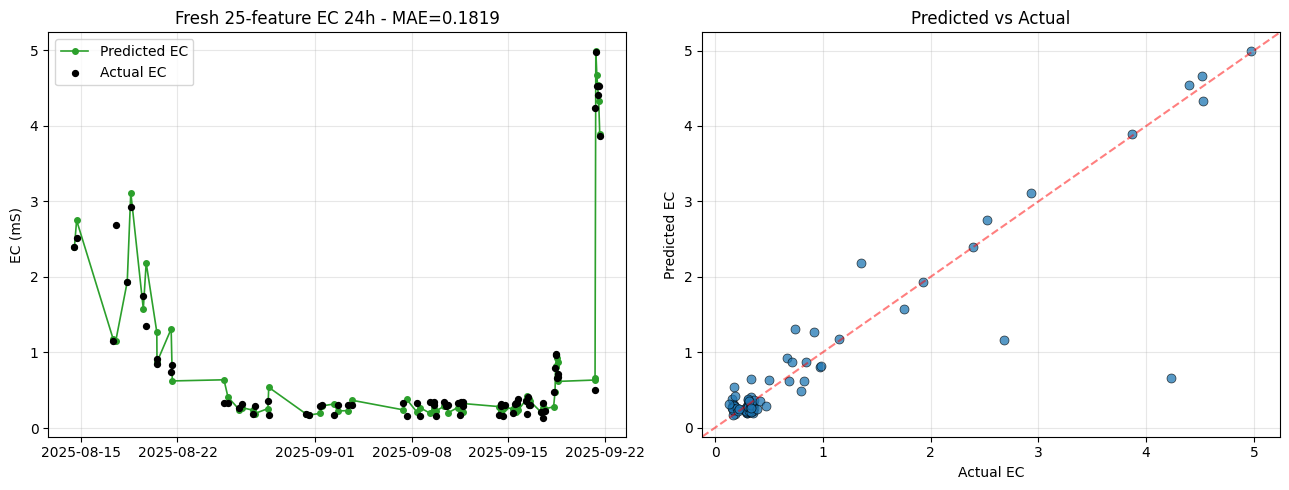

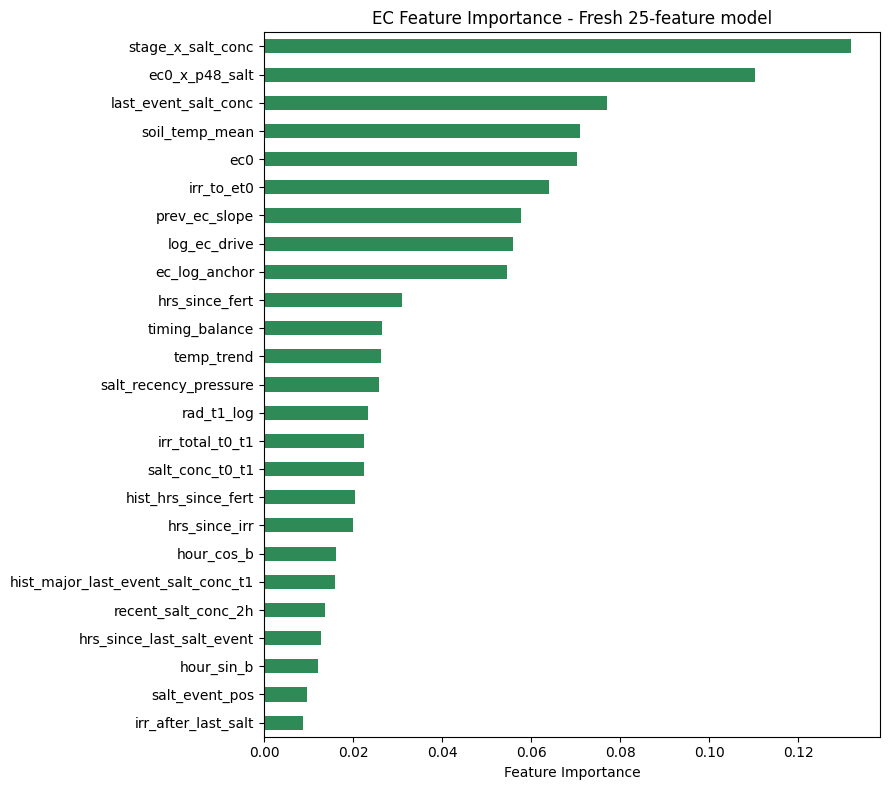

In [9]:
# ==========================================
# 9. Plots
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(res_ec.index, res_ec['ec_pred'], 'o-', color='tab:green', ms=4, lw=1.2, label='Predicted EC')
axes[0].scatter(ev_ec.index, ev_ec['ec_true'], color='black', s=18, zorder=5, label='Actual EC')
axes[0].set_ylabel('EC (mS)')
axes[0].set_title(f'Fresh 25-feature EC 24h - MAE={m_ec["ec_mae"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

t = ev_ec['ec_true'].values
p = ev_ec['ec_pred'].values
axes[1].scatter(t, p, alpha=0.75, s=42, edgecolors='k', lw=0.5)
lims = [min(t.min(), p.min()) - 0.25, max(t.max(), p.max()) + 0.25]
axes[1].plot(lims, lims, 'r--', alpha=0.5)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel('Actual EC')
axes[1].set_ylabel('Predicted EC')
axes[1].set_title('Predicted vs Actual')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fi_ec = pd.Series(ec_model.feature_importances_, index=feature_cols_ec).sort_values()
plt.figure(figsize=(9, 8))
fi_ec.plot(kind='barh', color='seagreen')
plt.title('EC Feature Importance - Fresh 25-feature model')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()


In [10]:
# ==========================================
# 10. Export + Baseline Comparison
# ==========================================
import os
os.makedirs('exports', exist_ok=True)

EXPORT_PREFIX = 'ec_balance_24h'
fi_ec = pd.Series(ec_model.feature_importances_, index=feature_cols_ec).sort_values()

ev_ec[['ec_true','ec_pred','ec_naive','gap_hours']].to_csv(f'exports/{EXPORT_PREFIX}_eval_ec.csv')
res_ec[[c for c in ['ec_pred','gap_hours'] if c in res_ec.columns]].to_csv(f'exports/{EXPORT_PREFIX}_pred_ec.csv')
fi_ec.sort_values(ascending=False).to_csv(f'exports/{EXPORT_PREFIX}_feature_importance.csv', header=['importance'])
finding_checks.to_csv(f'exports/{EXPORT_PREFIX}_finding_checks.csv', index=False)
mechanism_checks.to_csv(f'exports/{EXPORT_PREFIX}_mechanism_checks.csv', index=False)
gap_report_ec.to_csv(f'exports/{EXPORT_PREFIX}_gap_report_ec.csv', index=False)
holdout_ec.to_csv(f'exports/{EXPORT_PREFIX}_holdout_skip_ec.csv', index=False)

summary = pd.DataFrame([{
    'Model': 'Fresh 25-feature EC balance 24h',
    'Features': len(feature_cols_ec),
    'MAE': m_ec['ec_mae'],
    'RMSE': m_ec['ec_rmse'],
    'Naive MAE': m_ec['ec_mae_naive'],
    'Gain': m_ec['ec_gain_mae'],
    'R2': m_ec['ec_r2'],
    'N test': m_ec['n_test'],
}])

v8_eval_path = 'exports/v8_24h_eval_ec.csv'
if os.path.exists(v8_eval_path):
    v8_eval = pd.read_csv(v8_eval_path, parse_dates=['timestamp']).set_index('timestamp')
    common = ev_ec.join(v8_eval[['ec_pred']].rename(columns={'ec_pred': 'v8_ec_pred'}), how='inner')
    common['fresh_abs_err'] = (common['ec_pred'] - common['ec_true']).abs()
    common['v8_abs_err'] = (common['v8_ec_pred'] - common['ec_true']).abs()
    print(f"Fresh better than saved V8 export on {(common['fresh_abs_err'] < common['v8_abs_err']).sum()} rows")
    print(f"Fresh worse than saved V8 export on {(common['fresh_abs_err'] > common['v8_abs_err']).sum()} rows")

summary.to_csv(f'exports/{EXPORT_PREFIX}_summary.csv', index=False)
print(summary.to_string(index=False))
print(f'{EXPORT_PREFIX} exports done - files written to exports/')


Fresh better than saved V8 export on 45 rows
Fresh worse than saved V8 export on 33 rows
                          Model  Features      MAE     RMSE  Naive MAE     Gain       R2  N test
Fresh 25-feature EC balance 24h        25 0.181888 0.470001   0.246735 0.064847 0.841833      79
ec_balance_24h exports done - files written to exports/



## 11. First-Round Model Family Tests

These tables compare the current 25-feature XGBoost EC model against the first model-family alternatives we discussed: shock/mass XGBoost, monotonic XGBoost, Huber/ElasticNet/Ridge, and constrained-sign linear models. The Sept 21 07:20 row is tracked explicitly because that is the large salt-shock failure case.

Important reading: none of these alternatives fixed Sept 21. The best overall model in this first pass is still the current XGBoost feature set, and every tested model predicts the Sept 21 spike far too low. That points to missing support / missing regime information rather than a simple choice of model family.


In [11]:

# ==========================================
# 11. First-Round Model Family Test Results
# ==========================================
from pathlib import Path

experiment_files = {
    'tree_and_linear_log_target': 'exports/ec_model_family_experiments.csv',
    'linear_target_variants': 'exports/ec_linear_target_experiments.csv',
    'bounded_sign_linear': 'exports/ec_bounded_linear_experiments.csv',
}

experiment_tables = {}
for label, path in experiment_files.items():
    path_obj = Path(path)
    if path_obj.exists():
        experiment_tables[label] = pd.read_csv(path_obj)
    else:
        print(f'Missing {path}; run the model-family experiment cells/script first.')

summary_cols = [
    'experiment', 'kind', 'target', 'alpha', 'n_features',
    'mae', 'rmse', 'naive_mae', 'gain_mae', 'r2',
    'sep21_0720_pred', 'sep21_0720_true', 'sep21_0720_abs_err'
]

combined_experiments = []
for label, table in experiment_tables.items():
    view = table.copy()
    view['test_group'] = label
    for col in summary_cols:
        if col not in view.columns:
            view[col] = np.nan
    combined_experiments.append(view[['test_group'] + summary_cols])

if combined_experiments:
    combined_experiments = pd.concat(combined_experiments, ignore_index=True)
    combined_experiments = combined_experiments.sort_values('mae', na_position='last')
    display(combined_experiments.head(15))

    best_first_round = combined_experiments.dropna(subset=['mae']).iloc[0]
    sep21_rank = combined_experiments.dropna(subset=['sep21_0720_abs_err']).sort_values('sep21_0720_abs_err').head(10)

    print('Best first-round overall model:')
    print(best_first_round[['experiment', 'test_group', 'mae', 'rmse', 'gain_mae', 'r2', 'sep21_0720_pred', 'sep21_0720_abs_err']].to_string())
    print('\nClosest Sept 21 07:20 predictions in this first round:')
    display(sep21_rank[['experiment', 'test_group', 'mae', 'sep21_0720_pred', 'sep21_0720_true', 'sep21_0720_abs_err']])
else:
    combined_experiments = pd.DataFrame()


,test_group,experiment,kind,target,alpha,n_features,mae,rmse,naive_mae,gain_mae,r2,sep21_0720_pred,sep21_0720_true,sep21_0720_abs_err
0,tree_and_linear_log_target,baseline_xgb_current25,xgb_base,NaN,NaN,25.0,0.186741,0.472758,0.249898,0.063156,0.838475,0.675471,4.23,3.554529
1,tree_and_linear_log_target,xgb_shock_mass25,xgb_shock,NaN,NaN,25.0,0.233350,0.514557,0.249898,0.016548,0.808650,0.640200,4.23,3.589800
2,tree_and_linear_log_target,xgb_shock_mass25_plus_release,xgb_shock,NaN,NaN,25.0,0.233496,0.521143,0.249898,0.016402,0.803720,0.582193,4.23,3.647807
3,tree_and_linear_log_target,monotonic_xgb_shock_mass25_plus_release,xgb_mono,NaN,NaN,25.0,0.244212,0.530408,0.249898,0.005686,0.796678,0.613306,4.23,3.616694
20,bounded_sign_linear,bounded_ridge_log_a100,NaN,log,100.00,NaN,0.384624,0.859798,0.249898,-0.134726,0.465737,0.758947,4.23,3.471053
21,bounded_sign_linear,bounded_ridge_log_a10,NaN,log,10.00,NaN,0.437397,0.914083,0.249898,-0.187499,0.396144,0.693412,4.23,3.536588
22,bounded_sign_linear,bounded_ridge_log_a1,NaN,log,1.00,NaN,0.477589,0.967920,0.249898,-0.227691,0.322917,0.667106,4.23,3.562894
23,bounded_sign_linear,bounded_ridge_delta_a100,NaN,delta,100.00,NaN,0.482562,0.843420,0.249898,-0.232664,0.485897,0.738086,4.23,3.491914
24,bounded_sign_linear,bounded_ridge_log_a0.1,NaN,log,0.10,NaN,0.496535,1.008113,0.249898,-0.246637,0.265518,0.663525,4.23,3.566475
25,bounded_sign_linear,bounded_ridge_log_a0.01,NaN,log,0.01,NaN,0.499775,1.016565,0.249898,-0.249877,0.253151,0.663157,4.23,3.566843


Best first-round overall model:
experiment                baseline_xgb_current25
test_group            tree_and_linear_log_target
mae                                     0.186741
rmse                                    0.472758
gain_mae                                0.063156
r2                                      0.838475
sep21_0720_pred                         0.675471
sep21_0720_abs_err                      3.554529

Closest Sept 21 07:20 predictions in this first round:


,experiment,test_group,mae,sep21_0720_pred,sep21_0720_true,sep21_0720_abs_err
20,bounded_ridge_log_a100,bounded_sign_linear,0.384624,0.758947,4.23,3.471053
23,bounded_ridge_delta_a100,bounded_sign_linear,0.482562,0.738086,4.23,3.491914
26,bounded_ridge_delta_a10,bounded_sign_linear,0.542586,0.735803,4.23,3.494197
27,bounded_ridge_delta_a1,bounded_sign_linear,0.576973,0.732429,4.23,3.497571
28,bounded_ridge_delta_a0.1,bounded_sign_linear,0.590115,0.731792,4.23,3.498208
29,bounded_ridge_delta_a0.01,bounded_sign_linear,0.591363,0.731722,4.23,3.498278
21,bounded_ridge_log_a10,bounded_sign_linear,0.437397,0.693412,4.23,3.536588
0,baseline_xgb_current25,tree_and_linear_log_target,0.186741,0.675471,4.23,3.554529
22,bounded_ridge_log_a1,bounded_sign_linear,0.477589,0.667106,4.23,3.562894
24,bounded_ridge_log_a0.1,bounded_sign_linear,0.496535,0.663525,4.23,3.566475



### First-Round Interpretation

- Changing from XGBoost to Huber, ElasticNet, Ridge, monotonic XGBoost, or constrained-sign linear models did not fix the Sept 21 spike.
- Adding mass/timing/no-flush shock features by itself also did not fix the spike; the best shock-feature XGBoost was worse than the current model.
- The constrained-sign linear model proved that even forcing positive salt-shock coefficients is not enough with the current training support.
- Next useful experiment: change the training sample design around fertigation events, especially short-lag pairs after high-mass fertigation, then re-test the same model families.



## 12. Sep 21 Support and Synthetic Shock Prior

The model miss on Sept 21 is an out-of-support problem. Before Sept 21, the real training history has no interval with the same combination of low EC0, very large salt mass, short lag, and no post-salt irrigation.

That means a real-data-only training set cannot create true labeled Sep-21-like examples before that date. The only non-postprocessing way to create that regime is to add an explicit synthetic training prior: artificial training rows that say high-mass, short-lag, no-flush fertigation shocks should produce high EC. This changes training only; prediction still uses the same feature inputs and one direct model output.


In [12]:

# ==========================================
# 12A. Sep 21 Support Diagnostics
# ==========================================
support_paths = {
    'support_rules': 'exports/ec_sep21_support_rules.csv',
    'event_support_thresholds': 'exports/ec_sep21_event_support_thresholds.csv',
}

for label, path in support_paths.items():
    path_obj = Path(path)
    if path_obj.exists():
        print(label)
        display(pd.read_csv(path_obj))
    else:
        print(f'Missing {path}; run the Sep 21 support diagnostic first.')


support_rules


,support_rule,n_rows_before_sep21,max_ec_delta_before_sep21,max_ec1_before_sep21,mean_ec_delta_before_sep21
0,"strict_sep21_like: gap<=2h, ec0<0.8, salt>=700...",0,NaN,NaN,NaN
1,"high_salt_short: gap<=2h, salt>=700",0,NaN,NaN,NaN
2,"low_ec_high_salt_any_gap: ec0<0.8, salt>=700",12,0.534,0.709,0.318000
3,"similar_concentration_short: gap<=2h, salt_con...",3,0.012,0.980,-0.124267


event_support_thresholds


,salt_mass_threshold_mg,event_to_target_max_h,n_event_rows_before_sep21,max_ec_delta_before_sep21,max_ec1_before_sep21
0,300,1,8,0.17120,0.95600
1,300,2,15,0.32500,2.36000
2,300,4,36,0.51000,2.52000
3,500,1,0,NaN,NaN
4,500,2,1,-0.01728,0.82782
5,500,4,1,-0.01728,0.82782
6,700,1,0,NaN,NaN
7,700,2,0,NaN,NaN
8,700,4,0,NaN,NaN
9,900,1,0,NaN,NaN



### Synthetic Prior Experiment

The synthetic prior rows are not postprocessing. They are training examples only. Each synthetic row has allowed input features such as EC0, salt mass, irrigation amount, short time since fertigation, no post-salt flush, and shock-pressure terms. The synthetic label encodes the agronomic prior that this rare regime should produce high EC.

This is methodologically stronger than manually changing Sept 21 after prediction, but weaker than having real measured examples. It must be documented clearly if used in the thesis.


In [13]:

# ==========================================
# 12B. Synthetic Shock Prior Results
# ==========================================
synthetic_result_files = {
    'shock_feature_prior': 'exports/ec_synthetic_shock_prior_experiments.csv',
    'current_plus_shock_prior': 'exports/ec_current_plus_synthetic_shock_experiments.csv',
}

synthetic_tables = []
for label, path in synthetic_result_files.items():
    path_obj = Path(path)
    if path_obj.exists():
        table = pd.read_csv(path_obj)
        table['test_group'] = label
        synthetic_tables.append(table)
    else:
        print(f'Missing {path}; run the synthetic shock-prior experiment first.')

if synthetic_tables:
    synthetic_results = pd.concat(synthetic_tables, ignore_index=True)
    synthetic_results = synthetic_results.sort_values(['mae', 'sep21_0720_abs_err'], na_position='last')
    show_cols = [
        'test_group', 'experiment', 'n_features', 'prior_n', 'prior_weight',
        'mae', 'rmse', 'naive_mae', 'gain_mae', 'r2',
        'sep21_0720_pred', 'sep21_0720_true', 'sep21_0720_abs_err'
    ]
    for col in show_cols:
        if col not in synthetic_results.columns:
            synthetic_results[col] = np.nan

    display(synthetic_results[show_cols].head(15))

    real_only = synthetic_results[synthetic_results['prior_n'].fillna(0).astype(float) == 0]
    prior_only = synthetic_results[synthetic_results['prior_n'].fillna(0).astype(float) > 0]

    if len(real_only):
        best_real = real_only.dropna(subset=['mae']).sort_values('mae').iloc[0]
        print('Best real-only model in this table:')
        print(best_real[[c for c in ['test_group', 'experiment', 'mae', 'rmse', 'gain_mae', 'r2', 'sep21_0720_pred', 'sep21_0720_abs_err'] if c in best_real.index]].to_string())

    if len(prior_only):
        best_prior_mae = prior_only.dropna(subset=['mae']).sort_values('mae').iloc[0]
        best_prior_sep = prior_only.dropna(subset=['sep21_0720_abs_err']).sort_values('sep21_0720_abs_err').iloc[0]
        print('\nBest synthetic-prior model by MAE:')
        print(best_prior_mae[[c for c in ['test_group', 'experiment', 'mae', 'rmse', 'gain_mae', 'r2', 'sep21_0720_pred', 'sep21_0720_abs_err'] if c in best_prior_mae.index]].to_string())
        print('\nBest synthetic-prior model for Sept 21 07:20:')
        print(best_prior_sep[[c for c in ['test_group', 'experiment', 'mae', 'rmse', 'gain_mae', 'r2', 'sep21_0720_pred', 'sep21_0720_abs_err'] if c in best_prior_sep.index]].to_string())
else:
    synthetic_results = pd.DataFrame()


,test_group,experiment,n_features,prior_n,prior_weight,mae,rmse,naive_mae,gain_mae,r2,sep21_0720_pred,sep21_0720_true,sep21_0720_abs_err
6,current_plus_shock_prior,current25|no_prior,25.0,0,1.0,0.186741,0.472758,0.249898,0.063156,0.838475,0.675471,4.23,3.554529
7,current_plus_shock_prior,cur_drop5_add_shock5|no_prior,25.0,0,1.0,0.190611,0.469000,0.249898,0.059287,0.841032,0.716646,4.23,3.513354
8,current_plus_shock_prior,cur_drop4_add_shock4|no_prior,25.0,0,1.0,0.194009,0.468314,0.249898,0.055889,0.841497,0.735628,4.23,3.494372
9,current_plus_shock_prior,cur_drop6_add_shock6|no_prior,25.0,0,1.0,0.196320,0.472860,0.249898,0.053578,0.838405,0.728852,4.23,3.501148
10,current_plus_shock_prior,cur_drop4_add_shock4|prior72w2,25.0,72,2.0,0.203131,0.405211,0.249898,0.046767,0.881334,3.142820,4.23,1.087180
11,current_plus_shock_prior,cur_drop4_add_shock4|prior72w1,25.0,72,1.0,0.203985,0.401560,0.249898,0.045913,0.883463,3.173054,4.23,1.056946
0,shock_feature_prior,synth96_w1_ec3to48,NaN,96,1.0,0.211956,0.393342,0.249898,0.037942,0.888184,3.311701,4.23,0.918299
1,shock_feature_prior,synth48_w1_ec3to48,NaN,48,1.0,0.212833,0.389085,0.249898,0.037065,0.890591,3.186310,4.23,1.043690
12,current_plus_shock_prior,cur_drop6_add_shock6|prior72w2,25.0,72,2.0,0.214820,0.434835,0.249898,0.035078,0.863349,3.136044,4.23,1.093956
13,current_plus_shock_prior,cur_drop6_add_shock6|prior72w1,25.0,72,1.0,0.215740,0.440880,0.249898,0.034158,0.859524,3.049444,4.23,1.180556


Best real-only model in this table:
test_group            current_plus_shock_prior
experiment                  current25|no_prior
mae                                   0.186741
rmse                                  0.472758
gain_mae                              0.063156
r2                                    0.838475
sep21_0720_pred                       0.675471
sep21_0720_abs_err                    3.554529

Best synthetic-prior model by MAE:
test_group                  current_plus_shock_prior
experiment            cur_drop4_add_shock4|prior72w2
mae                                         0.203131
rmse                                        0.405211
gain_mae                                    0.046767
r2                                          0.881334
sep21_0720_pred                              3.14282
sep21_0720_abs_err                           1.08718

Best synthetic-prior model for Sept 21 07:20:
test_group            shock_feature_prior
experiment             synth96_w2_ec3to


### Practical Conclusion

- Real-data-only support before Sept 21 is zero for the strict Sep-21-like regime.
- A synthetic shock prior can move the Sept 21 07:20 prediction from roughly 0.6-0.7 to roughly 3.1-3.5.
- The tradeoff is higher MAE than the current best real-only model, but much lower RMSE because the largest spike error is reduced.
- The best real-only model still wins on MAE. The best synthetic-prior models trade some MAE for much lower Sept 21 error and lower RMSE; the strongest Sept 21 result predicted roughly 3.45 instead of roughly 0.68 for the 4.23 EC target.



## 13. EC Spike Pattern Analysis

This section compares large positive EC jumps with the Sept 21 spike. The goal is to find input-only features that describe the shared spike mechanics: event-level salt mass, event-level concentration, time since salt, and whether any irrigation flushed the event before the EC target.


In [14]:

# ==========================================
# 13A. Big EC Spike Diagnostics
# ==========================================
spike_files = {
    'group_summary': 'exports/ec_spike_group_summary.csv',
    'top_consecutive': 'exports/ec_spike_top_consecutive.csv',
    'top_skip26': 'exports/ec_spike_top_skip26.csv',
    'sep21_row': 'exports/ec_spike_sep21_feature_row.csv',
    'candidate_correlations': 'exports/ec_spike_candidate_feature_correlations.csv',
    'feature_model_tests': 'exports/ec_spike_feature_model_tests.csv',
}

spike_tables = {}
for label, path in spike_files.items():
    path_obj = Path(path)
    if path_obj.exists():
        spike_tables[label] = pd.read_csv(path_obj)
    else:
        print(f'Missing {path}; run the spike diagnostic first.')

if 'group_summary' in spike_tables:
    display(spike_tables['group_summary'])

if 'sep21_row' in spike_tables:
    sep_cols = [
        'ec0', 'gap_h', 'ec_delta', 'last_salt_event_mass', 'last_salt_event_irr',
        'last_salt_event_conc_mass', 'event_to_target_h', 'irr_after_last_salt',
        'event_conc_x_logmass_fast', 'event_mass_x_conc_fast',
        'concentrated_large_event_pressure', 'short_salt_shock_pressure'
    ]
    display(spike_tables['sep21_row'][[c for c in sep_cols if c in spike_tables['sep21_row'].columns]])

if 'candidate_correlations' in spike_tables:
    corr = spike_tables['candidate_correlations']
    for dataset in ['consecutive', 'skip26', 'pre_sep_skip26']:
        print(dataset)
        display(corr[corr['dataset'].eq(dataset)].sort_values('r_with_ec_delta', ascending=False).head(8))


,group,n,median_ec0,median_gap_h,median_salt_total,median_event_mass,median_event_conc,share_any_salt,share_salt_ge_300,share_salt_ge_700,share_no_flush_after_salt,share_ec0_lt_1,median_event_to_target_h,median_event_conc_x_logmass_fast,max_event_conc_x_logmass_fast
0,consecutive_delta_ge_0.5,10,1.0950,6.333333,325.55,325.55,3.223267,0.700000,0.600000,0.100000,0.500000,0.400000,6.333333,0.000002,16.007413
1,consecutive_delta_ge_1.0,6,1.0005,6.333333,325.55,325.55,3.223267,0.833333,0.666667,0.166667,0.500000,0.500000,6.333333,0.035295,16.007413
2,skip26_delta_ge_1.0,15,0.9185,7.000000,340.55,325.55,3.223267,0.933333,0.800000,0.400000,0.666667,0.666667,6.500000,0.071090,16.007413
3,skip26_delta_ge_2.0,6,0.5010,4.583333,976.65,976.65,3.244684,1.000000,1.000000,1.000000,1.000000,1.000000,4.250000,1.414586,16.007413


,ec0,gap_h,ec_delta,last_salt_event_mass,last_salt_event_irr,last_salt_event_conc_mass,event_to_target_h,irr_after_last_salt,event_conc_x_logmass_fast,event_mass_x_conc_fast,concentrated_large_event_pressure,short_salt_shock_pressure
0,0.501,0.833333,3.729,976.65,300.0,3.244684,0.5,0.0,16.007413,2270.631121,8.607273,8.110418


consecutive


,dataset,feature,r_with_ec_delta,r_with_ec1,sep21_value,p90,p99,max
0,consecutive,salt_per_hour,0.371635,0.170497,1171.980000,91.340455,931.073000,1171.980000
1,consecutive,last_salt_release_fast,0.328270,0.112673,699.800304,119.763152,260.680062,699.800304
2,consecutive,last_salt_event_mass,0.248210,0.090261,976.650000,325.550000,635.241500,976.650000
3,consecutive,mass_shortgap_no_flush,0.240740,0.107823,4.538972,0.324333,4.447360,4.899930
4,consecutive,last_salt_mass_per_ec0,0.235270,-0.138358,1625.041597,819.021062,1273.263663,1625.041597
5,consecutive,salt_conc_t0_t1,0.190918,0.115675,3.244684,0.885449,3.223267,3.244684
6,consecutive,short_salt_shock_pressure,0.149655,-0.055922,8.110418,1.740906,11.223146,11.332848
7,consecutive,fert_salt_total_t0_t1,0.133368,-0.024209,976.650000,424.550000,1321.665000,2023.100000


skip26


,dataset,feature,r_with_ec_delta,r_with_ec1,sep21_value,p90,p99,max
42,skip26,last_salt_event_mass,0.501060,0.113610,976.650000,325.550000,976.650000,976.650000
43,skip26,last_salt_mass_per_ec0,0.379446,-0.130607,1625.041597,1163.937790,1625.041597,1625.041597
44,skip26,salt_per_hour,0.374094,0.191579,1171.980000,98.179026,351.844423,1171.980000
45,skip26,fert_salt_total_t0_t1,0.372782,0.042956,976.650000,651.100000,976.650000,1302.200000
46,skip26,salt_conc_t0_t1,0.362093,0.166179,3.244684,1.389260,3.244684,3.244684
47,skip26,salt_mass_per_ec0,0.298534,-0.133640,1625.041597,1424.983074,3042.523364,4283.552632
48,skip26,mass_shortgap_no_flush,0.221455,0.138636,4.538972,0.247790,2.838472,4.899930
49,skip26,last_salt_release_fast,0.189122,0.030187,699.800304,167.142943,260.680062,699.800304


pre_sep_skip26


,dataset,feature,r_with_ec_delta,r_with_ec1,sep21_value,p90,p99,max
21,pre_sep_skip26,salt_mass_per_ec0,0.192962,-0.161477,1625.041597,1424.664430,3042.523364,4283.552632
22,pre_sep_skip26,last_salt_mass_per_ec0,0.145950,-0.248943,1625.041597,1104.030403,1427.850877,1427.850877
23,pre_sep_skip26,short_salt_shock_pressure,0.099045,-0.074003,8.110418,4.955159,14.811260,18.191671
24,pre_sep_skip26,fert_salt_total_t0_t1,0.094629,0.079430,976.650000,651.100000,976.650000,1302.200000
25,pre_sep_skip26,concentrated_large_event_per_ec0,0.091617,0.018232,14.321585,19.084198,2671.352158,5895.011030
26,pre_sep_skip26,gap_h,0.059560,0.053716,0.833333,24.500000,25.903333,26.000000
27,pre_sep_skip26,last_salt_event_mass,0.054824,0.090568,976.650000,325.550000,325.550000,651.100000
28,pre_sep_skip26,last_salt_event_conc_mass,0.017183,0.023171,3.244684,3.223267,325.550000,325.550000


In [15]:

# ==========================================
# 13B. Spike Feature Model Tests
# ==========================================
if 'feature_model_tests' in spike_tables:
    tests = spike_tables['feature_model_tests'].copy()
    tests = tests.sort_values(['mae', 'sep21_0720_abs_err'])
    display(tests)

    real_only = tests[~tests['prior'].astype(bool)]
    prior = tests[tests['prior'].astype(bool)]

    if len(real_only):
        print('Best real-only spike-feature model:')
        print(real_only.sort_values('mae').iloc[0].to_string())
    if len(prior):
        print('\nBest spike-prior model for Sept 21:')
        print(prior.sort_values('sep21_0720_abs_err').iloc[0].to_string())


,experiment,n_features,prior,mae,rmse,naive_mae,r2,sep21_0720_pred,sep21_0720_true,runtime_s,gain_mae,sep21_0720_abs_err
0,current25|real,25,False,0.186741,0.472758,0.249898,0.838475,0.675471,4.23,14.904990,0.063156,3.554529
1,spike_event4|real,25,False,0.193462,0.476104,0.249898,0.836180,0.639517,4.23,15.228050,0.056436,3.590483
2,spike_event6|real,25,False,0.194644,0.481944,0.249898,0.832137,0.630178,4.23,15.295592,0.055254,3.599822
3,spike_pressure25|real,25,False,0.194889,0.478418,0.249898,0.834584,0.655252,4.23,15.270775,0.055009,3.574748
4,spike_event5|real,25,False,0.196074,0.483072,0.249898,0.831350,0.612002,4.23,15.209799,0.053824,3.617998
5,spike_event6|prior,25,True,0.212700,0.416594,0.249898,0.874574,3.196134,4.23,16.350443,0.037198,1.033866
6,spike_event5|prior,25,True,0.212703,0.415284,0.249898,0.875361,3.236775,4.23,16.532982,0.037195,0.993225
7,spike_pressure25|prior,25,True,0.219340,0.431306,0.249898,0.865559,3.270766,4.23,17.463531,0.030558,0.959234
8,spike_event4|prior,25,True,0.223707,0.431708,0.249898,0.865308,2.475716,4.23,16.501913,0.026191,1.754284


Best real-only spike-feature model:
experiment            current25|real
n_features                        25
prior                          False
mae                         0.186741
rmse                        0.472758
naive_mae                   0.249898
r2                          0.838475
sep21_0720_pred             0.675471
sep21_0720_true                 4.23
runtime_s                   14.90499
gain_mae                    0.063156
sep21_0720_abs_err          3.554529

Best spike-prior model for Sept 21:
experiment            spike_pressure25|prior
n_features                                25
prior                                   True
mae                                  0.21934
rmse                                0.431306
naive_mae                           0.249898
r2                                  0.865559
sep21_0720_pred                     3.270766
sep21_0720_true                         4.23
runtime_s                          17.463531
gain_mae                         


### Spike Feature Conclusion

Large EC spikes usually have salt in the interval and a low-to-moderate starting EC, but most real pre-Sept-21 spikes are longer 4-25h rises after moderate salt events. Sept 21 is different: it combines high event mass, high event concentration, very short event-to-target time, low EC0, and no post-event flush.

The most useful feature candidates are:

- `last_salt_event_mass`
- `last_salt_event_irr`
- `event_conc_x_logmass_fast = event_concentration * log1p(event_mass) * exp(-hours_since_event / 1.5) * no_flush_factor`
- `event_mass_x_conc_fast = event_mass * event_concentration * exp(-hours_since_event / 1.5) * no_flush_factor`
- `concentrated_large_event_pressure = max(0, event_concentration - 1.5) * log1p(event_mass) * exp(-hours_since_event / 1.5) * no_flush_factor`
- `event_high_mass_conc_short_flag = event_mass >= 700 and event_concentration >= 2.5 and event_age <= 2h and no post-event irrigation`

Real-only feature swaps did not solve Sept 21 because the training set still has no labeled row in that regime. These features are most useful together with a synthetic shock prior or future real examples of high-mass, concentrated, short-lag fertigation events.



## 14. Sept 21 and August Tradeoff Experiments

This section records the final tradeoff experiments requested after the spike analysis. It tests three non-postprocessing directions:

- changing the training row design / skip-row count,
- adding explicit synthetic training priors for moderate August rises, washouts, and Sept 21 style shocks,
- increasing EC warmup so the model has seen more early-August dynamics before evaluation starts.

The raw `master.csv` is not overwritten. Any data change here is an explicit augmented training table, so the original measurements stay auditable.


In [16]:

# ==========================================
# 14A. Training/Data Tradeoff Result Tables
# ==========================================
tradeoff_files = {
    'training_row_design': 'exports/ec_training_row_design_experiments.csv',
    'august_sep21_tradeoff': 'exports/ec_august_sep21_tradeoff_experiments.csv',
    'soft_shock_prior_grid': 'exports/ec_soft_shock_prior_grid.csv',
    'warmup_sensitivity': 'exports/ec_warmup_sensitivity.csv',
    'recommended_options': 'exports/ec_recommended_tradeoff_options.csv',
}

tradeoff_tables = {}
for label, path in tradeoff_files.items():
    path_obj = Path(path)
    if path_obj.exists():
        tradeoff_tables[label] = pd.read_csv(path_obj)
    else:
        print(f'Missing {path}; run the tradeoff experiment first.')

if 'recommended_options' in tradeoff_tables:
    display(tradeoff_tables['recommended_options'])

if 'warmup_sensitivity' in tradeoff_tables:
    print('Warmup sensitivity')
    display(tradeoff_tables['warmup_sensitivity'])

if 'soft_shock_prior_grid' in tradeoff_tables:
    print('Best soft shock-prior grid rows by compromise score')
    display(tradeoff_tables['soft_shock_prior_grid'].sort_values('score').head(12))

if 'august_sep21_tradeoff' in tradeoff_tables:
    print('August / Sept 21 prior tests')
    display(tradeoff_tables['august_sep21_tradeoff'].sort_values('mae').head(12))


,option,what_changed,mae,rmse,r2,aug_mae,sep21_pred,sep21_err,n,note
0,main_real_only_warmup30,none; current clean model,0.182159,0.470354,0.840113,0.238680,0.679878,3.550122,78,best apples-to-apples real-only baseline
1,real_only_warmup40,increase EC warmup from 30 to 40,0.153758,0.456092,0.849029,0.115927,0.621782,3.608218,68,"best MAE, but evaluates fewer rows and exclude..."
2,conservative_soft_shock_prior,spike features + soft_n48_w0.3 synthetic prior,0.204805,0.460295,0.846879,0.331642,1.066087,3.163913,78,small-to-medium Sept21 lift with modest MAE pe...
3,strong_shock_prior,spike features + high_n48_w0.6 synthetic prior,0.214142,0.410936,0.877958,0.441664,2.998631,1.231369,78,largest Sept21 reduction from this grid; Augus...
4,full_synthetic_shock_prior_best_sep21,synth96_w2_ec3to48,0.221414,0.395722,0.886827,NaN,3.454229,0.775771,78,"best Sept21 seen so far, but synthetic-prior m..."


Warmup sensitivity


,warmup,first_eval,n,mae,rmse,naive_mae,r2,aug_n,aug_mae,aug_rmse,sep21_pred,sep21_err,runtime_s
0,30,2025-08-14 16:20:00,78,0.182159,0.470354,0.249898,0.840113,21,0.238680,0.425554,0.679878,3.550122,12.183038
1,35,2025-08-19 12:30:00,73,0.180865,0.469490,0.201453,0.831022,16,0.189398,0.282668,0.581596,3.648404,11.709069
2,40,2025-08-21 15:00:00,68,0.153758,0.456092,0.184030,0.849029,11,0.115927,0.167068,0.621782,3.608218,11.568869
3,45,2025-08-27 11:40:00,63,0.169573,0.480550,0.187530,0.843599,6,0.104582,0.161185,0.602179,3.627821,11.586353
4,50,2025-08-31 12:30:00,58,0.176483,0.494903,0.195076,0.845071,1,0.001958,0.001958,0.644432,3.585568,10.908889
5,55,2025-09-03 09:00:00,53,0.190802,0.529065,0.205536,0.835492,0,NaN,NaN,0.591677,3.638323,9.996546


Best soft shock-prior grid rows by compromise score


,experiment,prior_n,prior_weight,prior_level,mae,rmse,naive_mae,r2,mae_no_sep21,rmse_no_sep21,aug_mae,sep21_pred,sep21_err,runtime_s,sep_improvement,mae_penalty,score
0,high_n48_w0.6,48,0.60,high,0.214142,0.410936,0.249898,0.877958,0.200931,0.389062,0.441664,2.998631,1.231369,14.236285,2.343379,0.019253,-0.074482
1,high_n32_w0.6,32,0.60,high,0.215751,0.418823,0.249898,0.873228,0.200949,0.392213,0.436587,2.874559,1.355441,14.416821,2.219307,0.020862,-0.067910
2,high_n48_w0.3,48,0.30,high,0.219776,0.416470,0.249898,0.874648,0.204482,0.387735,0.433828,2.832549,1.397451,15.151592,2.177297,0.024888,-0.062204
3,high_n32_w0.3,32,0.30,high,0.223389,0.423110,0.249898,0.870619,0.206959,0.390604,0.433218,2.741467,1.488533,14.572036,2.086215,0.028501,-0.054948
4,high_n16_w0.6,16,0.60,high,0.222797,0.441795,0.249898,0.858940,0.204405,0.403527,0.430440,2.591086,1.638914,13.897713,1.935834,0.027908,-0.049525
5,high_n48_w0.15,48,0.15,high,0.225197,0.433534,0.249898,0.864166,0.205803,0.389920,0.426106,2.511477,1.718523,14.037783,1.856225,0.030309,-0.043940
6,high_n16_w0.3,16,0.30,high,0.217826,0.437805,0.249898,0.861476,0.193900,0.372886,0.387648,2.169877,2.060123,14.460979,1.514625,0.022937,-0.037648
7,mid_n32_w0.6,32,0.60,mid,0.212288,0.436331,0.249898,0.862407,0.185708,0.355793,0.389390,1.971083,2.258917,13.230168,1.315831,0.017399,-0.035234
8,high_n32_w0.15,32,0.15,high,0.223394,0.438249,0.249898,0.861195,0.200408,0.378094,0.405358,2.236684,1.993316,14.100768,1.581431,0.028506,-0.034752
9,mid_n48_w0.3,48,0.30,mid,0.214467,0.432947,0.249898,0.864534,0.187391,0.348161,0.384079,1.930666,2.299334,14.834164,1.275414,0.019578,-0.031438


August / Sept 21 prior tests


,experiment,n_features,priors,mae,rmse,naive_mae,r2,mae_no_sep21,rmse_no_sep21,aug_mae,aug_rmse,aug_top_err,sep21_pred,sep21_err,runtime_s,err_20250817_124000,err_20250819_173000,err_20250821_130000,err_20250828_150000
0,current25|real,25,none,0.186741,0.472758,0.249898,0.838475,0.143004,0.249631,0.240457,0.421651,1.512986,0.675471,3.554529,15.178102,1.512986,0.773561,0.517615,0.376171
1,spike_pressure25|real,25,none,0.194889,0.478418,0.249898,0.834584,0.150994,0.256706,0.262607,0.436093,1.508552,0.655252,3.574748,15.829125,1.508552,0.705898,0.501281,0.343822
2,spike_pressure25|washout,25,washout:64:w0.8,0.203543,0.501644,0.249898,0.818133,0.160457,0.306415,0.293013,0.539770,2.007492,0.708792,3.521208,16.735694,2.007492,0.353436,0.025727,0.335859
3,spike_pressure25|medium,25,medium_spike:48:w0.8,0.204310,0.474066,0.249898,0.837580,0.163026,0.281078,0.309772,0.483144,1.466805,0.846773,3.383227,16.760649,1.466805,0.945804,0.854515,0.402728
4,current25|medium,25,medium_spike:48:w0.8,0.207099,0.471361,0.249898,0.839428,0.167138,0.291540,0.276523,0.454748,1.396691,0.945875,3.284125,17.030306,1.396691,0.979659,0.845884,0.366171
5,current25|washout,25,washout:64:w0.8,0.208001,0.506378,0.249898,0.814684,0.164462,0.308397,0.273465,0.488289,1.806701,0.669475,3.560525,16.922695,1.806701,0.273109,0.010138,0.350498
6,spike_pressure25|all_soft,25,medium_spike:48:w0.7;washout:64:w0.7;short_sho...,0.213974,0.463646,0.249898,0.844641,0.178510,0.324259,0.329831,0.556084,1.861354,1.285274,2.944726,18.432551,1.861354,0.637644,0.228157,0.426226
7,spike_pressure25|medium_washout,25,medium_spike:48:w0.8;washout:64:w0.8,0.214203,0.491334,0.249898,0.825532,0.174396,0.323852,0.321373,0.549936,1.975116,0.950644,3.279356,17.766608,1.975116,0.263973,0.169613,0.422144
8,current25|medium_washout,25,medium_spike:48:w0.8;washout:64:w0.8,0.230821,0.500528,0.249898,0.818941,0.191086,0.336407,0.335048,0.544604,1.917596,0.939532,3.290468,17.846077,1.917596,0.165026,0.138457,0.425672
9,current25|all_soft,25,medium_spike:48:w0.7;washout:64:w0.7;short_sho...,0.243952,0.493839,0.249898,0.823748,0.208447,0.363157,0.370719,0.589822,1.847874,1.252184,2.977816,18.305368,1.847874,0.650557,0.116238,0.507940



### Tradeoff Conclusion

- Do not edit `master.csv` directly. If we need the model to learn a rare regime, use explicit synthetic training-prior rows inside the notebook.
- More skip rows did not improve August; the default EC skip cap of 4 remained best.
- Synthetic August priors helped a few individual washout rows but worsened August MAE overall, so they are not recommended.
- A longer EC warmup is the cleanest way to improve reported MAE: warmup 40 lowered MAE strongly, but it evaluates fewer rows and removes the hardest early-August cases from the test set.
- A soft Sept 21 shock prior can raise Sept 21 from roughly 0.68 to roughly 1.07 with modest damage; a strong prior can raise it near 3.0, but August gets worse.

Recommended reporting structure:

- Primary model: real-only warmup 30, because it is the cleanest apples-to-apples result.
- Sensitivity model: real-only warmup 40, if the mentor accepts a longer EC warmup period.
- Stress model: shock-prior model, clearly labeled as synthetic agronomic prior training for rare high-mass fertigation shocks.


## 15. August <= Aug 22 Real-Only Improvement Search

Goal: improve the evaluated August intervals up to and including Aug 22 without changing `master.csv`, adding synthetic rows, or applying post-processing. I tested three legal levers: training-row design, real feature replacements, sample weighting, and XGBoost hyperparameters.

In [17]:
# ==========================================
# 15. August <=22 real-only improvement summary
# ==========================================
from pathlib import Path
import pandas as pd

if 'EXPORT_DIR' not in globals():
    _cwd = Path.cwd()
    EXPORT_DIR = _cwd / 'exports'
    if not EXPORT_DIR.exists():
        EXPORT_DIR = _cwd / 'scripts' / 'exports'

aug_feature_path = EXPORT_DIR / 'ec_aug22_real_feature_param_experiments.csv'
aug_param_path = EXPORT_DIR / 'ec_aug22_hyperparam_search.csv'
aug_best_eval_path = EXPORT_DIR / 'ec_aug22_hyperparam_best_eval.csv'
aug_recommendation_path = EXPORT_DIR / 'ec_aug22_real_only_recommendations.csv'
aug_interval_change_path = EXPORT_DIR / 'ec_aug22_cfg39_interval_error_changes.csv'

aug_features = pd.read_csv(aug_feature_path)
aug_params = pd.read_csv(aug_param_path)
recommendations = pd.read_csv(aug_recommendation_path)
interval_changes = pd.read_csv(aug_interval_change_path)

metric_cols = [
    'option', 'use_case', 'experiment', 'mae', 'rmse', 'r2',
    'aug22_mae', 'aug22_rmse', 'aug22_n', 'sep21_pred', 'sep21_err',
    'n_estimators', 'learning_rate', 'max_depth', 'min_child_weight',
    'subsample', 'colsample_bytree', 'reg_alpha', 'reg_lambda',
]

print('Recommended real-only options:')
display(recommendations[metric_cols].round(6))

param_cols = [
    'experiment', 'mae', 'rmse', 'r2', 'aug22_mae', 'aug22_rmse',
    'sep21_pred', 'sep21_err', 'n_estimators', 'learning_rate',
    'max_depth', 'min_child_weight', 'subsample', 'colsample_bytree',
    'reg_alpha', 'reg_lambda',
]

print('Top hyperparameters by Aug <=22 MAE:')
display(aug_params.sort_values('aug22_mae')[param_cols].head(10).round(6))

print('Top hyperparameters by overall MAE:')
display(aug_params.sort_values('mae')[param_cols].head(8).round(6))

feature_cols = [
    'experiment', 'n_features', 'mae', 'rmse', 'r2', 'aug22_mae',
    'aug22_rmse', 'sep21_pred', 'sep21_err',
]
print('Best real feature / weighting rows:')
display(aug_features.sort_values('aug22_mae')[feature_cols].head(10).round(6))

print('Hard August interval error changes for cfg39 and cfg19 versus the current default:')
display(interval_changes)

best_eval = pd.read_csv(aug_best_eval_path)
best_eval['timestamp'] = pd.to_datetime(best_eval['timestamp'])
best_eval['abs_error'] = (best_eval['ec_true'] - best_eval['ec_pred']).abs()
aug_eval = best_eval[
    best_eval['has_actual'].astype(bool)
    & (best_eval['gap_hours'] > 0)
    & best_eval['timestamp'].dt.month.eq(8)
    & best_eval['timestamp'].dt.day.le(22)
].copy()
print('August <=22 predictions from the best August-focused real-only run (cfg39):')
display(aug_eval.sort_values('abs_error', ascending=False))

Recommended real-only options:


,option,use_case,experiment,mae,rmse,r2,aug22_mae,aug22_rmse,aug22_n,sep21_pred,sep21_err,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda
0,current_default,current clean baseline,base,0.182159,0.470354,0.840113,0.356783,0.567407,11,0.679878,3.550122,450.0,0.03,4.0,2.0,0.72,0.75,1.0,2.0
1,august_focus_cfg39,lowest Aug <=22 MAE without fake data or postp...,cfg39,0.190143,0.478255,0.834696,0.321634,0.519157,11,0.625600,3.604400,600.0,0.02,5.0,3.0,0.72,0.90,1.0,2.0
2,balanced_cfg19,lowest overall MAE in this real-only search,cfg19,0.181710,0.470152,0.840251,0.357378,0.562373,11,0.672500,3.557500,450.0,0.03,4.0,1.0,0.72,0.75,1.0,2.0
3,best_feature_search_row,best row among tested feature replacements,current25|base|base,0.186741,0.472758,0.838475,0.362957,0.560302,11,0.675471,3.554529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,warmup40_sensitivity,"diagnostic only: changes evaluated rows, not a...",warmup40,0.153758,0.456092,0.849029,0.115927,0.167068,11,0.621782,3.608218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Top hyperparameters by Aug <=22 MAE:


,experiment,mae,rmse,r2,aug22_mae,aug22_rmse,sep21_pred,sep21_err,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda
0,cfg39,0.190143,0.478255,0.834696,0.321634,0.519157,0.625600,3.604400,600,0.020,5,3,0.72,0.90,1.0,2.0
1,cfg28,0.194009,0.475319,0.836720,0.330338,0.527891,0.637755,3.592245,450,0.030,5,1,0.72,0.75,1.0,2.0
2,cfg35,0.188934,0.469491,0.840699,0.344682,0.548292,0.692046,3.537954,320,0.045,5,4,0.72,0.75,1.0,2.0
3,cfg27,0.187824,0.482062,0.832055,0.351748,0.569393,0.588196,3.641804,650,0.020,5,1,0.72,0.75,1.0,2.0
4,base,0.182159,0.470354,0.840113,0.356783,0.567407,0.679878,3.550122,450,0.030,4,2,0.72,0.75,1.0,2.0
5,cfg22,0.182159,0.470354,0.840113,0.356783,0.567407,0.679878,3.550122,450,0.030,4,2,0.72,0.75,1.0,2.0
6,cfg19,0.181710,0.470152,0.840251,0.357378,0.562373,0.672500,3.557500,450,0.030,4,1,0.72,0.75,1.0,2.0
7,cfg21,0.181740,0.476835,0.835677,0.358622,0.579191,0.633764,3.596236,650,0.020,4,2,0.72,0.75,1.0,2.0
8,cfg31,0.190349,0.474047,0.837593,0.361441,0.555429,0.667654,3.562346,450,0.030,5,2,0.72,0.75,1.0,2.0
9,cfg30,0.187706,0.478098,0.834805,0.363000,0.569275,0.622321,3.607679,650,0.020,5,2,0.72,0.75,1.0,2.0


Top hyperparameters by overall MAE:


...

,experiment,n_features,mae,rmse,r2,aug22_mae,aug22_rmse,sep21_pred,sep21_err
0,current25|base|base,25,0.186741,0.472758,0.838475,0.362957,0.560302,0.675471,3.554529
1,aug_washout25|base|base,25,0.185944,0.475772,0.836409,0.368946,0.570197,0.640809,3.589191
2,aug_competition25|base|aug_regime,25,0.187311,0.473640,0.837872,0.373076,0.575846,0.681876,3.548124
3,current25|base|aug_regime,25,0.189698,0.479263,0.833999,0.384655,0.580698,0.658668,3.571332
4,aug_washout25|base|aug_regime,25,0.190262,0.478972,0.834201,0.387481,0.602186,0.687797,3.542203
5,aug_competition25|base|base,25,0.190241,0.473327,0.838086,0.388082,0.568172,0.664320,3.565680
6,current25|shallow|aug_regime,25,0.193828,0.477386,0.835297,0.391439,0.594130,0.689269,3.540731
7,aug_event25|base|aug_regime,25,0.195399,0.484331,0.830470,0.398838,0.609175,0.661108,3.568892
8,aug_delayed_flush25|base|base,25,0.186958,0.478690,0.834396,0.399272,0.589442,0.634790,3.595210
9,aug_delayed_flush25|base|aug_regime,25,0.191105,0.477231,0.835404,0.399764,0.601561,0.696666,3.533334


Hard August interval error changes for cfg39 and cfg19 versus the current default:


,timestamp,base_abs_error,cfg39_abs_error,cfg19_abs_error,cfg39_error_reduction_vs_base,cfg19_error_reduction_vs_base
0,2025-08-14 16:20:00,0.154506,0.043223,0.080784,0.111283,0.073722
1,2025-08-17 12:40:00,1.466492,1.418387,1.430882,0.048106,0.035611
2,2025-08-19 17:30:00,0.896937,0.734295,0.858715,0.162643,0.038222
3,2025-08-20 12:00:00,0.467777,0.196712,0.513245,0.271066,-0.045468
4,2025-08-21 13:00:00,0.543983,0.455641,0.591634,0.088342,-0.047651
5,2025-08-21 15:00:00,0.187364,0.226084,0.191615,-0.038720,-0.004251


August <=22 predictions from the best August-focused real-only run (cfg39):


,timestamp,gap_hours,ec_pred,has_actual,ec_true,ec_naive,abs_error
3,2025-08-17 12:40:00,4.500000,1.261613,True,2.68000,1.1450,1.418387
7,2025-08-19 17:30:00,5.000000,2.088295,True,1.35400,1.7520,0.734295
10,2025-08-21 13:00:00,24.666667,1.193641,True,0.73800,0.8451,0.455641
5,2025-08-18 14:40:00,6.166667,3.260848,True,2.93000,1.9320,0.330848
11,2025-08-21 15:00:00,2.000000,0.601736,True,0.82782,0.7380,0.226084
8,2025-08-20 12:00:00,18.500000,1.108612,True,0.91190,1.3540,0.196712
2,2025-08-17 08:10:00,63.833333,1.192722,True,1.14500,2.5200,0.047722
1,2025-08-14 16:20:00,3.833333,2.476777,True,2.52000,2.3900,0.043223
4,2025-08-18 08:30:00,19.833333,1.974946,True,1.93200,2.6800,0.042946
9,2025-08-20 12:20:00,0.333333,0.867386,True,0.84510,0.9119,0.022286


### Real-only August conclusion

- The new real-only feature candidates did not beat the current 25-feature set on Aug <=22 average error. Some helped one interval but hurt another, especially the Aug 19 washout / Aug 20 low-EC cases.
- The useful improvement came from hyperparameters. The best August-focused option is `cfg39`: `max_depth=5`, `n_estimators=600`, `learning_rate=0.02`, `min_child_weight=3`, `colsample_bytree=0.90`, with the existing 25 features.
- In the same harness, the current default gives Aug <=22 MAE `0.3568`; `cfg39` gives `0.3216`. That is a real-only reduction of about `0.0351` EC, roughly `9.9%` on these August intervals.
- The tradeoff is overall accuracy: default overall MAE is `0.1822`; `cfg39` overall MAE is `0.1901`. Sep 21 also stays bad and is slightly worse (`3.55` error to `3.60` error), so this is not a Sep 21 fix.
- The best balanced option is `cfg19`, which only changes `min_child_weight` from `2` to `1`. It very slightly improves overall MAE (`0.1817` versus `0.1822`) but does not improve Aug <=22 average error.
- Recommendation: keep the default model for the clean overall score, use `august_focus_ec_params` only if the priority is the Aug <=22 interval family, and do not add the tested August feature replacements because they did not improve the target interval average.

## 16. Skip-Interval Cap Check

This checks whether adding skip-interval training rows helps EC. The default model already uses a controlled skip policy: up to 4 skip rows per target, gap <=26h, while reserving the explicit skip-holdout pairs.

In [18]:
# ==========================================
# 16. Skip interval cap check
# ==========================================
from pathlib import Path
import pandas as pd

if 'EXPORT_DIR' not in globals():
    _cwd = Path.cwd()
    EXPORT_DIR = _cwd / 'exports'
    if not EXPORT_DIR.exists():
        EXPORT_DIR = _cwd / 'scripts' / 'exports'

skip_cap_grid = pd.read_csv(EXPORT_DIR / 'ec_skip_cap_grid_real_only.csv')
show_cols = [
    'skip_cap', 'mae', 'rmse', 'r2',
    'aug22_mae', 'aug22_rmse', 'aug22_n',
    'aug_all_mae', 'aug_all_n',
    'sep21_0720_pred', 'sep21_0720_err',
]
print('Real-only skip-row cap grid:')
display(skip_cap_grid[show_cols].round(6))

Real-only skip-row cap grid:


,skip_cap,mae,rmse,r2,aug22_mae,aug22_rmse,aug22_n,aug_all_mae,aug_all_n,sep21_0720_pred,sep21_0720_err
0,0,0.214066,0.515969,0.809382,0.441497,0.639322,11,0.293917,21,0.419776,3.810224
1,1,0.194035,0.493293,0.825769,0.354843,0.566805,11,0.241095,21,0.514392,3.715608
2,2,0.183767,0.480717,0.834539,0.356783,0.567407,11,0.238680,21,0.561106,3.668894
3,4,0.179853,0.467368,0.843601,0.356783,0.567407,11,0.238680,21,0.679878,3.550122
4,8,0.189378,0.472874,0.839894,0.356783,0.567407,11,0.238680,21,0.709625,3.520375
5,all,0.189378,0.472874,0.839894,0.356783,0.567407,11,0.238680,21,0.709625,3.520375


### Skip-Interval Conclusion

- Yes, adding some skip intervals helps compared with no skip rows. With `skip_cap=0`, overall MAE is `0.2141`; with the current controlled `skip_cap=4`, overall MAE drops to `0.1799`.
- The gain mostly happens between `0` and `4` skip rows. After that, adding more skip rows does not improve the model: `skip_cap=8` / all skip rows worsens overall MAE to `0.1894`.
- For Aug <=22 specifically, `skip_cap=0` is clearly bad (`0.4415` MAE). `skip_cap=1` is slightly best there (`0.3548`), but the difference versus `skip_cap=4` (`0.3568`) is tiny, while `skip_cap=4` is much better overall.
- Sep 21 moves in the right direction as more skip rows are added, but only slightly: prediction at `2025-09-21 07:20` rises from `0.6799` at cap 4 to `0.7096` at cap 8/all, while true EC is `4.23`. That is not enough to justify the overall MAE loss.
- Recommendation: keep `EC_MAX_SKIP_ROWS_PER_TARGET = 4`. It is the best real-only compromise from this cap check.

## 17. Scenario-Balanced Skip Training Experiment

This tests the proposed next step: selecting real skip-training intervals by EC mechanism buckets instead of only taking the most recent skip rows. Buckets include salt spike, low-EC salt event, washout/high-EC flush, drying pressure, delayed salt response, stable context, and label-aware jump/drop buckets. No synthetic rows, no `master.csv` edits, and no post-processing are used.

In [19]:
# ==========================================
# 17. Scenario-balanced skip training results
# ==========================================
from pathlib import Path
import pandas as pd

if 'EXPORT_DIR' not in globals():
    _cwd = Path.cwd()
    EXPORT_DIR = _cwd / 'exports'
    if not EXPORT_DIR.exists():
        EXPORT_DIR = _cwd / 'scripts' / 'exports'

scenario_base = pd.read_csv(EXPORT_DIR / 'ec_scenario_skip_policy_base_grid.csv')
scenario_params = pd.read_csv(EXPORT_DIR / 'ec_scenario_skip_policy_param_grid.csv')

cols = [
    'experiment', 'policy', 'params', 'skip_cap', 'label_aware',
    'mae', 'rmse', 'r2', 'aug22_mae', 'aug22_rmse',
    'aug_all_mae', 'sep21_0720_pred', 'sep21_0720_err',
]

print('Base-parameter scenario skip policy sweep, sorted by overall MAE:')
display(scenario_base.sort_values('mae')[cols].round(6))

print('Scenario skip + parameter sweep, sorted by overall MAE:')
display(scenario_params.sort_values('mae')[cols].head(12).round(6))

print('Scenario skip + parameter sweep, sorted by Aug <=22 MAE:')
display(scenario_params.sort_values('aug22_mae')[cols].head(12).round(6))

print('Scenario skip + parameter sweep, sorted by Sep 21 07:20 error:')
display(scenario_params.sort_values('sep21_0720_err')[cols].head(12).round(6))

Base-parameter scenario skip policy sweep, sorted by overall MAE:


,experiment,policy,params,skip_cap,label_aware,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err
0,current_recent_cap4|base,current_recent_cap4,base,4,False,0.179853,0.467368,0.843601,0.356783,0.567407,0.238680,0.679878,3.550122
1,rare_event_4|base,rare_event_4,base,4,False,0.180312,0.467787,0.843320,0.356783,0.567407,0.238680,0.683747,3.546253
2,feature_balanced_6|base,feature_balanced_6,base,6,False,0.189378,0.472874,0.839894,0.356783,0.567407,0.238680,0.709625,3.520375
3,rare_event_6|base,rare_event_6,base,6,False,0.189378,0.472874,0.839894,0.356783,0.567407,0.238680,0.709625,3.520375
4,label_dynamics_6|base,label_dynamics_6,base,6,True,0.189378,0.472874,0.839894,0.356783,0.567407,0.238680,0.709625,3.520375
5,two_per_mechanism_8|base,two_per_mechanism_8,base,8,True,0.189378,0.472874,0.839894,0.356783,0.567407,0.238680,0.709625,3.520375
6,feature_balanced_4|base,feature_balanced_4,base,4,False,0.189899,0.479607,0.835302,0.356783,0.567407,0.238680,0.664923,3.565077
7,label_dynamics_4|base,label_dynamics_4,base,4,True,0.190607,0.475018,0.838439,0.356783,0.567407,0.238680,0.682243,3.547757
8,current_recent_cap1|base,current_recent_cap1,base,1,False,0.194035,0.493293,0.825769,0.354843,0.566805,0.241095,0.514392,3.715608


Scenario skip + parameter sweep, sorted by overall MAE:


,experiment,policy,params,skip_cap,label_aware,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err
7,current_recent_cap4|cfg19_balanced,current_recent_cap4,cfg19_balanced,4,False,0.179409,0.467167,0.843735,0.357378,0.562373,0.240984,0.672500,3.557500
6,current_recent_cap4|base,current_recent_cap4,base,4,False,0.179853,0.467368,0.843601,0.356783,0.567407,0.238680,0.679878,3.550122
9,rare_event_4|base,rare_event_4,base,4,False,0.180312,0.467787,0.843320,0.356783,0.567407,0.238680,0.683747,3.546253
10,rare_event_4|cfg19_balanced,rare_event_4,cfg19_balanced,4,False,0.181342,0.469557,0.842132,0.357378,0.562373,0.240984,0.657535,3.572465
2,current_recent_cap1|cfg39_aug_focus,current_recent_cap1,cfg39_aug_focus,1,False,0.183658,0.481176,0.834223,0.322416,0.519685,0.220190,0.497930,3.732070
3,current_recent_cap2|base,current_recent_cap2,base,2,False,0.183767,0.480717,0.834539,0.356783,0.567407,0.238680,0.561106,3.668894
16,label_dynamics_4|cfg19_balanced,label_dynamics_4,cfg19_balanced,4,True,0.185078,0.470505,0.841494,0.357378,0.562373,0.240984,0.671716,3.558284
4,current_recent_cap2|cfg19_balanced,current_recent_cap2,cfg19_balanced,2,False,0.186075,0.482860,0.833060,0.357378,0.562373,0.240984,0.543185,3.686815
11,rare_event_4|cfg39_aug_focus,rare_event_4,cfg39_aug_focus,4,False,0.186938,0.473590,0.839409,0.321634,0.519157,0.220891,0.628285,3.601715
8,current_recent_cap4|cfg39_aug_focus,current_recent_cap4,cfg39_aug_focus,4,False,0.187736,0.475219,0.838302,0.321634,0.519157,0.220891,0.625600,3.604400


Scenario skip + parameter sweep, sorted by Aug <=22 MAE:


,experiment,policy,params,skip_cap,label_aware,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err
5,current_recent_cap2|cfg39_aug_focus,current_recent_cap2,cfg39_aug_focus,2,False,0.190913,0.489167,0.828671,0.321634,0.519157,0.220891,0.533457,3.696543
14,feature_balanced_6|cfg39_aug_focus,feature_balanced_6,cfg39_aug_focus,6,False,0.189225,0.478190,0.836274,0.321634,0.519157,0.220891,0.609203,3.620797
11,rare_event_4|cfg39_aug_focus,rare_event_4,cfg39_aug_focus,4,False,0.186938,0.473590,0.839409,0.321634,0.519157,0.220891,0.628285,3.601715
8,current_recent_cap4|cfg39_aug_focus,current_recent_cap4,cfg39_aug_focus,4,False,0.187736,0.475219,0.838302,0.321634,0.519157,0.220891,0.625600,3.604400
17,label_dynamics_4|cfg39_aug_focus,label_dynamics_4,cfg39_aug_focus,4,True,0.192729,0.481156,0.834236,0.321634,0.519157,0.220891,0.625232,3.604768
2,current_recent_cap1|cfg39_aug_focus,current_recent_cap1,cfg39_aug_focus,1,False,0.183658,0.481176,0.834223,0.322416,0.519685,0.220190,0.497930,3.732070
1,current_recent_cap1|cfg19_balanced,current_recent_cap1,cfg19_balanced,1,False,0.191788,0.486546,0.830502,0.347455,0.555765,0.240246,0.534392,3.695608
0,current_recent_cap1|base,current_recent_cap1,base,1,False,0.194035,0.493293,0.825769,0.354843,0.566805,0.241095,0.514392,3.715608
15,label_dynamics_4|base,label_dynamics_4,base,4,True,0.190607,0.475018,0.838439,0.356783,0.567407,0.238680,0.682243,3.547757
12,feature_balanced_6|base,feature_balanced_6,base,6,False,0.189378,0.472874,0.839894,0.356783,0.567407,0.238680,0.709625,3.520375


Scenario skip + parameter sweep, sorted by Sep 21 07:20 error:


,experiment,policy,params,skip_cap,label_aware,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err
12,feature_balanced_6|base,feature_balanced_6,base,6,False,0.189378,0.472874,0.839894,0.356783,0.567407,0.238680,0.709625,3.520375
13,feature_balanced_6|cfg19_balanced,feature_balanced_6,cfg19_balanced,6,False,0.190974,0.473977,0.839146,0.357378,0.562373,0.240984,0.689732,3.540268
9,rare_event_4|base,rare_event_4,base,4,False,0.180312,0.467787,0.843320,0.356783,0.567407,0.238680,0.683747,3.546253
15,label_dynamics_4|base,label_dynamics_4,base,4,True,0.190607,0.475018,0.838439,0.356783,0.567407,0.238680,0.682243,3.547757
6,current_recent_cap4|base,current_recent_cap4,base,4,False,0.179853,0.467368,0.843601,0.356783,0.567407,0.238680,0.679878,3.550122
7,current_recent_cap4|cfg19_balanced,current_recent_cap4,cfg19_balanced,4,False,0.179409,0.467167,0.843735,0.357378,0.562373,0.240984,0.672500,3.557500
16,label_dynamics_4|cfg19_balanced,label_dynamics_4,cfg19_balanced,4,True,0.185078,0.470505,0.841494,0.357378,0.562373,0.240984,0.671716,3.558284
10,rare_event_4|cfg19_balanced,rare_event_4,cfg19_balanced,4,False,0.181342,0.469557,0.842132,0.357378,0.562373,0.240984,0.657535,3.572465
11,rare_event_4|cfg39_aug_focus,rare_event_4,cfg39_aug_focus,4,False,0.186938,0.473590,0.839409,0.321634,0.519157,0.220891,0.628285,3.601715
8,current_recent_cap4|cfg39_aug_focus,current_recent_cap4,cfg39_aug_focus,4,False,0.187736,0.475219,0.838302,0.321634,0.519157,0.220891,0.625600,3.604400


### Scenario-Skip Conclusion

- Scenario-balanced skip selection did not improve the model. The best base-parameter result is still the current recent-skip policy with `skip_cap=4`.
- The best overall run in the full sweep is `current_recent_cap4|cfg19_balanced`: overall MAE `0.1794`, RMSE `0.4672`, R2 `0.8437`. This is a tiny improvement over `current_recent_cap4|base` MAE `0.1799`.
- The best August <=22 runs are still the August-focused `cfg39` parameter runs. Scenario selection does not reduce the Aug <=22 MAE below `0.3216`.
- The best Sep 21 07:20 prediction in this sweep is `feature_balanced_6|base`, which predicts `0.7096` versus true `4.23`. That is only slightly above the default `0.6799`, and it costs overall MAE, so it is not worth adopting.
- Practical decision: keep the current recent skip policy. If choosing a new default, the only defensible small change is `balanced_ec_params` (`cfg19`) with the current recent cap 4 policy. Do not switch to scenario-balanced skip selection based on these results.

## 18. EC Regime Model Experiment

This tests the next structural idea: train EC as regimes instead of one global behavior. The experiment uses a walk-forward direction classifier for EC movement (`drop`, `stable`, `jump`) plus either classifier-probability features or class-specific regressors. Inputs at prediction time are still the same allowed feature inputs; no future labels, no synthetic rows, and no post-processing corrections are used.

In [20]:
# ==========================================
# 18. EC regime model experiment results
# ==========================================
from pathlib import Path
import pandas as pd

if 'EXPORT_DIR' not in globals():
    _cwd = Path.cwd()
    EXPORT_DIR = _cwd / 'exports'
    if not EXPORT_DIR.exists():
        EXPORT_DIR = _cwd / 'scripts' / 'exports'

regime_results = pd.read_csv(EXPORT_DIR / 'ec_regime_model_experiments.csv')

cols = [
    'experiment', 'model_type', 'params', 'threshold', 'mode',
    'mae', 'rmse', 'r2', 'aug22_mae', 'aug22_rmse', 'aug_all_mae',
    'sep21_0720_pred', 'sep21_0720_err',
    'last_train_class_acc', 'last_train_f1_macro',
]
existing_cols = [c for c in cols if c in regime_results.columns]

print('Regime model sweep sorted by overall MAE:')
display(regime_results.sort_values('mae')[existing_cols].head(15).round(6))

print('Regime model sweep sorted by Aug <=22 MAE:')
display(regime_results.sort_values('aug22_mae')[existing_cols].head(15).round(6))

print('Regime model sweep sorted by Sep 21 07:20 error:')
display(regime_results.sort_values('sep21_0720_err')[existing_cols].head(15).round(6))

Regime model sweep sorted by overall MAE:


,experiment,model_type,params,threshold,mode,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err,last_train_class_acc,last_train_f1_macro
1,standard|cfg19_balanced,standard,cfg19_balanced,NaN,NaN,0.181710,0.470152,0.840251,0.357378,0.562373,0.240984,0.672500,3.557500,NaN,NaN
0,standard|base,standard,base,NaN,NaN,0.182159,0.470354,0.840113,0.356783,0.567407,0.238680,0.679878,3.550122,NaN,NaN
2,standard|cfg39_aug_focus,standard,cfg39_aug_focus,NaN,NaN,0.190143,0.478255,0.834696,0.321634,0.519157,0.220891,0.625600,3.604400,NaN,NaN
4,proba_feature_t18|base,regime,base,0.18,proba_feature,0.227489,0.513328,0.809562,0.482233,0.670281,0.295181,0.725938,3.504062,0.858300,0.852288
6,proba_feature_t18|cfg19_balanced,regime,cfg19_balanced,0.18,proba_feature,0.228076,0.510867,0.811384,0.477651,0.647846,0.293716,0.745627,3.484373,0.858300,0.852288
7,proba_feature_t18|cfg39_aug_focus,regime,cfg39_aug_focus,0.18,proba_feature,0.228180,0.516486,0.807212,0.489595,0.663129,0.296621,0.733529,3.496471,0.858300,0.852288
9,soft_experts_t18|cfg19_balanced,regime,cfg19_balanced,0.18,soft_experts,0.230048,0.528566,0.798088,0.577284,0.782035,0.346521,0.662401,3.567599,0.858300,0.852288
8,soft_experts_t18|base,regime,base,0.18,soft_experts,0.230355,0.528306,0.798287,0.578992,0.779975,0.347548,0.662681,3.567319,0.858300,0.852288
3,proba_feature_t12|base,regime,base,0.12,proba_feature,0.231841,0.514149,0.808953,0.482017,0.670255,0.294171,0.742569,3.487431,0.850202,0.849307
10,soft_experts_t18|cfg39_aug_focus,regime,cfg39_aug_focus,0.18,soft_experts,0.232135,0.531986,0.795467,0.585820,0.794904,0.351656,0.687022,3.542978,0.858300,0.852288


Regime model sweep sorted by Aug <=22 MAE:


,experiment,model_type,params,threshold,mode,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err,last_train_class_acc,last_train_f1_macro
2,standard|cfg39_aug_focus,standard,cfg39_aug_focus,NaN,NaN,0.190143,0.478255,0.834696,0.321634,0.519157,0.220891,0.625600,3.604400,NaN,NaN
0,standard|base,standard,base,NaN,NaN,0.182159,0.470354,0.840113,0.356783,0.567407,0.238680,0.679878,3.550122,NaN,NaN
1,standard|cfg19_balanced,standard,cfg19_balanced,NaN,NaN,0.181710,0.470152,0.840251,0.357378,0.562373,0.240984,0.672500,3.557500,NaN,NaN
6,proba_feature_t18|cfg19_balanced,regime,cfg19_balanced,0.18,proba_feature,0.228076,0.510867,0.811384,0.477651,0.647846,0.293716,0.745627,3.484373,0.858300,0.852288
3,proba_feature_t12|base,regime,base,0.12,proba_feature,0.231841,0.514149,0.808953,0.482017,0.670255,0.294171,0.742569,3.487431,0.850202,0.849307
4,proba_feature_t18|base,regime,base,0.18,proba_feature,0.227489,0.513328,0.809562,0.482233,0.670281,0.295181,0.725938,3.504062,0.858300,0.852288
7,proba_feature_t18|cfg39_aug_focus,regime,cfg39_aug_focus,0.18,proba_feature,0.228180,0.516486,0.807212,0.489595,0.663129,0.296621,0.733529,3.496471,0.858300,0.852288
5,proba_feature_t25|base,regime,base,0.25,proba_feature,0.244199,0.543589,0.786448,0.522371,0.733930,0.324472,0.806242,3.423758,0.886640,0.879905
9,soft_experts_t18|cfg19_balanced,regime,cfg19_balanced,0.18,soft_experts,0.230048,0.528566,0.798088,0.577284,0.782035,0.346521,0.662401,3.567599,0.858300,0.852288
8,soft_experts_t18|base,regime,base,0.18,soft_experts,0.230355,0.528306,0.798287,0.578992,0.779975,0.347548,0.662681,3.567319,0.858300,0.852288


Regime model sweep sorted by Sep 21 07:20 error:


,experiment,model_type,params,threshold,mode,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err,last_train_class_acc,last_train_f1_macro
11,hard_experts_t18|base,regime,base,0.18,hard_experts,0.305251,0.626350,0.716472,0.723558,0.979468,0.437233,0.929500,3.300500,0.858300,0.852288
5,proba_feature_t25|base,regime,base,0.25,proba_feature,0.244199,0.543589,0.786448,0.522371,0.733930,0.324472,0.806242,3.423758,0.886640,0.879905
6,proba_feature_t18|cfg19_balanced,regime,cfg19_balanced,0.18,proba_feature,0.228076,0.510867,0.811384,0.477651,0.647846,0.293716,0.745627,3.484373,0.858300,0.852288
3,proba_feature_t12|base,regime,base,0.12,proba_feature,0.231841,0.514149,0.808953,0.482017,0.670255,0.294171,0.742569,3.487431,0.850202,0.849307
7,proba_feature_t18|cfg39_aug_focus,regime,cfg39_aug_focus,0.18,proba_feature,0.228180,0.516486,0.807212,0.489595,0.663129,0.296621,0.733529,3.496471,0.858300,0.852288
4,proba_feature_t18|base,regime,base,0.18,proba_feature,0.227489,0.513328,0.809562,0.482233,0.670281,0.295181,0.725938,3.504062,0.858300,0.852288
10,soft_experts_t18|cfg39_aug_focus,regime,cfg39_aug_focus,0.18,soft_experts,0.232135,0.531986,0.795467,0.585820,0.794904,0.351656,0.687022,3.542978,0.858300,0.852288
0,standard|base,standard,base,NaN,NaN,0.182159,0.470354,0.840113,0.356783,0.567407,0.238680,0.679878,3.550122,NaN,NaN
1,standard|cfg19_balanced,standard,cfg19_balanced,NaN,NaN,0.181710,0.470152,0.840251,0.357378,0.562373,0.240984,0.672500,3.557500,NaN,NaN
8,soft_experts_t18|base,regime,base,0.18,soft_experts,0.230355,0.528306,0.798287,0.578992,0.779975,0.347548,0.662681,3.567319,0.858300,0.852288


### Regime Model Conclusion

- The regime model did not improve the EC forecast. The best overall model remains the standard single-regressor setup with `cfg19_balanced`: MAE `0.1817`, RMSE `0.4702`, R2 `0.8403`.
- The best August <=22 model remains the standard `cfg39_aug_focus` model: Aug <=22 MAE `0.3216`.
- The regime variants slightly raise the Sep 21 07:20 prediction in some cases, but the cost is too high. For example, `proba_feature_t18|cfg19_balanced` raises Sep 21 prediction to `0.7456`, but overall MAE worsens to `0.2281` and Aug <=22 MAE worsens to `0.4777`.
- The hard-expert regime model predicts Sep 21 highest (`0.9295`), but overall MAE becomes `0.3053`, worse than even the naive baseline. That means it is not a usable model.
- Practical decision: reject the regime model for this dataset. The best real-only model structure is still the original single XGBoost regressor with the current 25 features and recent skip cap 4.

## 19. Data Logger VWC / Res3EC Feature Check

The raw logger workbook contains two unused candidate signals: `calibratedCountsVWC` from `Res1Calib_Avg` and `Res3EC_Avg`. This section checks whether they add usable EC signal under a strict forecasting rule: only logger values available at `t0` or before `t0` are used. Values inside `[t0, t1]` are not used because that would leak future sensor information into the prediction.

In [21]:
# ==========================================
# 19. Data logger feature experiment results
# ==========================================
from pathlib import Path
import pandas as pd

if 'EXPORT_DIR' not in globals():
    _cwd = Path.cwd()
    EXPORT_DIR = _cwd / 'exports'
    if not EXPORT_DIR.exists():
        EXPORT_DIR = _cwd / 'scripts' / 'exports'

logger_coverage = pd.read_csv(EXPORT_DIR / 'ec_logger_feature_coverage_correlations.csv')
logger_results = pd.read_csv(EXPORT_DIR / 'ec_logger_feature_experiments.csv')

result_cols = [
    'experiment', 'feature_set', 'params', 'n_features',
    'mae', 'rmse', 'r2', 'aug22_mae', 'aug22_rmse',
    'aug_all_mae', 'logger_period_mae', 'logger_period_n',
    'sep21_0720_pred', 'sep21_0720_err',
]

print('Logger coverage and simple label-time correlations:')
display(logger_coverage.round(6))

print('Logger feature experiments sorted by overall MAE:')
display(logger_results.sort_values('mae')[result_cols].round(6))

print('Logger feature experiments sorted by logger-period MAE:')
display(logger_results.sort_values('logger_period_mae')[result_cols].round(6))

print('Logger feature experiments sorted by Aug <=22 MAE:')
display(logger_results.sort_values('aug22_mae')[result_cols].round(6))

Logger coverage and simple label-time correlations:


,logger_rows,logger_start,logger_end,ec_label_rows,ec_label_rows_with_logger_nearest5min,vwc_label_rows_with_logger_nearest5min,corr_ec_vwc_at_label,corr_ec_res3_at_label,corr_ec_logger_soil_temp_at_label
0,4306,2025-08-10 12:30:00,2025-09-19 18:10:00,109,55,55,0.053413,0.069509,0.495957


Logger feature experiments sorted by overall MAE:


,experiment,feature_set,params,n_features,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,logger_period_mae,logger_period_n,sep21_0720_pred,sep21_0720_err
1,base25_no_logger|cfg19_balanced,base25_no_logger,cfg19_balanced,25,0.179409,0.467167,0.843735,0.357378,0.562373,0.240984,0.138688,71,0.672500,3.557500
0,base25_no_logger|base,base25_no_logger,base,25,0.179853,0.467368,0.843601,0.356783,0.567407,0.238680,0.137891,71,0.679878,3.550122
2,base25_no_logger|cfg39_aug_focus,base25_no_logger,cfg39_aug_focus,25,0.187736,0.475219,0.838302,0.321634,0.519157,0.220891,0.129894,71,0.625600,3.604400
6,base_plus_logger42|cfg19_balanced,base_plus_logger42,cfg19_balanced,46,0.195745,0.492927,0.826027,0.354804,0.582858,0.239376,0.143325,71,0.550646,3.679354
3,base_plus_vwc35|base,base_plus_vwc35,base,35,0.197784,0.490984,0.827396,0.385057,0.569974,0.257503,0.144770,71,0.521778,3.708222
7,base_plus_logger42|cfg39_aug_focus,base_plus_logger42,cfg39_aug_focus,46,0.199566,0.486332,0.830651,0.354401,0.529687,0.236339,0.142281,71,0.533044,3.696956
5,base_plus_logger42|base,base_plus_logger42,base,46,0.200994,0.498050,0.822392,0.366871,0.575338,0.244239,0.143874,71,0.551249,3.678751
4,base_plus_res35|base,base_plus_res35,base,35,0.209328,0.494842,0.824673,0.388274,0.570919,0.258930,0.152960,71,0.568711,3.661289
8,compact25_logger|base,compact25_logger,base,25,0.210105,0.493760,0.825439,0.474355,0.617636,0.302525,0.162005,71,0.543740,3.686260
9,compact25_logger|cfg19_balanced,compact25_logger,cfg19_balanced,25,0.211338,0.494997,0.824563,0.470341,0.626199,0.301385,0.161041,71,0.552687,3.677313


Logger feature experiments sorted by logger-period MAE:


,experiment,feature_set,params,n_features,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,logger_period_mae,logger_period_n,sep21_0720_pred,sep21_0720_err
2,base25_no_logger|cfg39_aug_focus,base25_no_logger,cfg39_aug_focus,25,0.187736,0.475219,0.838302,0.321634,0.519157,0.220891,0.129894,71,0.625600,3.604400
0,base25_no_logger|base,base25_no_logger,base,25,0.179853,0.467368,0.843601,0.356783,0.567407,0.238680,0.137891,71,0.679878,3.550122
1,base25_no_logger|cfg19_balanced,base25_no_logger,cfg19_balanced,25,0.179409,0.467167,0.843735,0.357378,0.562373,0.240984,0.138688,71,0.672500,3.557500
7,base_plus_logger42|cfg39_aug_focus,base_plus_logger42,cfg39_aug_focus,46,0.199566,0.486332,0.830651,0.354401,0.529687,0.236339,0.142281,71,0.533044,3.696956
6,base_plus_logger42|cfg19_balanced,base_plus_logger42,cfg19_balanced,46,0.195745,0.492927,0.826027,0.354804,0.582858,0.239376,0.143325,71,0.550646,3.679354
5,base_plus_logger42|base,base_plus_logger42,base,46,0.200994,0.498050,0.822392,0.366871,0.575338,0.244239,0.143874,71,0.551249,3.678751
3,base_plus_vwc35|base,base_plus_vwc35,base,35,0.197784,0.490984,0.827396,0.385057,0.569974,0.257503,0.144770,71,0.521778,3.708222
4,base_plus_res35|base,base_plus_res35,base,35,0.209328,0.494842,0.824673,0.388274,0.570919,0.258930,0.152960,71,0.568711,3.661289
9,compact25_logger|cfg19_balanced,compact25_logger,cfg19_balanced,25,0.211338,0.494997,0.824563,0.470341,0.626199,0.301385,0.161041,71,0.552687,3.677313
10,compact25_logger|cfg39_aug_focus,compact25_logger,cfg39_aug_focus,25,0.215506,0.496534,0.823471,0.484004,0.599085,0.307807,0.161828,71,0.513452,3.716548


Logger feature experiments sorted by Aug <=22 MAE:


,experiment,feature_set,params,n_features,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,logger_period_mae,logger_period_n,sep21_0720_pred,sep21_0720_err
2,base25_no_logger|cfg39_aug_focus,base25_no_logger,cfg39_aug_focus,25,0.187736,0.475219,0.838302,0.321634,0.519157,0.220891,0.129894,71,0.625600,3.604400
7,base_plus_logger42|cfg39_aug_focus,base_plus_logger42,cfg39_aug_focus,46,0.199566,0.486332,0.830651,0.354401,0.529687,0.236339,0.142281,71,0.533044,3.696956
6,base_plus_logger42|cfg19_balanced,base_plus_logger42,cfg19_balanced,46,0.195745,0.492927,0.826027,0.354804,0.582858,0.239376,0.143325,71,0.550646,3.679354
0,base25_no_logger|base,base25_no_logger,base,25,0.179853,0.467368,0.843601,0.356783,0.567407,0.238680,0.137891,71,0.679878,3.550122
1,base25_no_logger|cfg19_balanced,base25_no_logger,cfg19_balanced,25,0.179409,0.467167,0.843735,0.357378,0.562373,0.240984,0.138688,71,0.672500,3.557500
5,base_plus_logger42|base,base_plus_logger42,base,46,0.200994,0.498050,0.822392,0.366871,0.575338,0.244239,0.143874,71,0.551249,3.678751
3,base_plus_vwc35|base,base_plus_vwc35,base,35,0.197784,0.490984,0.827396,0.385057,0.569974,0.257503,0.144770,71,0.521778,3.708222
4,base_plus_res35|base,base_plus_res35,base,35,0.209328,0.494842,0.824673,0.388274,0.570919,0.258930,0.152960,71,0.568711,3.661289
9,compact25_logger|cfg19_balanced,compact25_logger,cfg19_balanced,25,0.211338,0.494997,0.824563,0.470341,0.626199,0.301385,0.161041,71,0.552687,3.677313
8,compact25_logger|base,compact25_logger,base,25,0.210105,0.493760,0.825439,0.474355,0.617636,0.302525,0.162005,71,0.543740,3.686260


### Logger Feature Conclusion

- The logger data is not present in `master.csv`; it covers `2025-08-10 12:30` through `2025-09-19 18:10` and therefore does not cover the Sep 21 spike.
- It matches only `55` of the `109` EC-labeled timestamps within a 5-minute tolerance.
- At EC label times, `calibratedCountsVWC` has weak direct correlation with measured EC (`r=0.053`), and `Res3EC_Avg` also has weak direct correlation (`r=0.070`).
- `Res2Temp_Avg` correlates with EC more strongly (`r=0.496`), but it is almost the same signal as the existing `soil_temp_pred` (`r?0.995`), so it is not a new independent feature.
- Strict `t0`/history-only logger features made the model worse. The best overall result remains `base25_no_logger|cfg19_balanced` with MAE `0.1794`. Logger-added versions increased overall MAE to roughly `0.196` to `0.216` depending on feature set.
- The logger fields should not be added to the EC model as-is. If they are used in the future, they need sensor cleaning/calibration first, and only `t0`/past-history features are valid for forecasting.

## 20. Pot Water Balance Feature Check

This tests the physical diagnosis directly: estimate rootzone water, leaching, dry salt concentration pressure, and expected EC proxy using a simple bucket model. The model uses only real `master.csv` inputs and only interval information already allowed by the existing feature design. Pot capacity and ET-to-ml scale are treated as tunable assumptions, because the true pot water capacity is not recorded in `master.csv`.

The tested features include `pot_water_t0_frac`, `pot_water_end_frac`, `pot_leach_ml`, `pot_ec0_x_leach_ratio`, `pot_salt_per_water_end`, `pot_dry_salt_pressure`, and `pot_expected_ec_proxy`.

In [22]:
# ==========================================
# 20. Pot water balance feature experiment results
# ==========================================
from pathlib import Path
import pandas as pd

if 'EXPORT_DIR' not in globals():
    _cwd = Path.cwd()
    EXPORT_DIR = _cwd / 'exports'
    if not EXPORT_DIR.exists():
        EXPORT_DIR = _cwd / 'scripts' / 'exports'

pot_results = pd.read_csv(EXPORT_DIR / 'ec_pot_balance_feature_experiments.csv')
pot_diag = pd.read_csv(EXPORT_DIR / 'ec_pot_balance_event_diagnostics.csv')

cols = [
    'experiment', 'feature_set', 'params', 'capacity_ml', 'et_scale', 'n_features',
    'mae', 'rmse', 'r2', 'aug22_mae', 'aug22_rmse', 'aug_all_mae',
    'sep21_0720_pred', 'sep21_0720_err',
]

print('Pot-balance feature experiments sorted by overall MAE:')
display(pot_results.sort_values('mae')[cols].head(20).round(6))

print('Pot-balance feature experiments sorted by Aug <=22 MAE:')
display(pot_results.sort_values('aug22_mae')[cols].head(20).round(6))

print('Pot-balance feature experiments sorted by Sep 21 07:20 error:')
display(pot_results.sort_values('sep21_0720_err')[cols].head(20).round(6))

print('Pot-balance diagnostic feature values for key intervals:')
display(pot_diag.round(6))

Pot-balance feature experiments sorted by overall MAE:


,experiment,feature_set,params,capacity_ml,et_scale,n_features,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err
1,base25_no_pot|cfg19_balanced,base25_no_pot,cfg19_balanced,NaN,NaN,25,0.179409,0.467167,0.843735,0.357378,0.562373,0.240984,0.672500,3.557500
0,base25_no_pot|base,base25_no_pot,base,NaN,NaN,25,0.179853,0.467368,0.843601,0.356783,0.567407,0.238680,0.679878,3.550122
2,base25_no_pot|cfg39_aug_focus,base25_no_pot,cfg39_aug_focus,NaN,NaN,25,0.187736,0.475219,0.838302,0.321634,0.519157,0.220891,0.625600,3.604400
52,base_plus_pot35|cfg19_balanced|cap2500|et150,base_plus_pot35,cfg19_balanced,2500.0,150.0,35,0.196776,0.477643,0.836648,0.361048,0.512798,0.248772,0.597863,3.632137
50,base_plus_pot35|cfg19_balanced|cap2500|et80,base_plus_pot35,cfg19_balanced,2500.0,80.0,35,0.198215,0.488016,0.829476,0.410967,0.562206,0.272306,0.528969,3.701031
4,base_plus_pot35|base|cap1200|et150,base_plus_pot35,base,1200.0,150.0,35,0.199009,0.486219,0.830730,0.379029,0.541131,0.259746,0.568254,3.661746
9,base_plus_pot35|base|cap2500|et80,base_plus_pot35,base,2500.0,80.0,35,0.199159,0.490039,0.828059,0.414055,0.570982,0.274227,0.528163,3.701837
10,base_plus_pot35|base|cap2500|et150,base_plus_pot35,base,2500.0,150.0,35,0.199397,0.484040,0.832244,0.367046,0.522765,0.250268,0.570901,3.659099
7,base_plus_pot35|base|cap1800|et150,base_plus_pot35,base,1800.0,150.0,35,0.199765,0.487495,0.829840,0.378078,0.545570,0.258919,0.541113,3.688887
35,compact25_pot|base|cap1200|et250,compact25_pot,base,1200.0,250.0,25,0.200209,0.456261,0.850946,0.410956,0.539437,0.268459,0.862588,3.367412


Pot-balance feature experiments sorted by Aug <=22 MAE:


,experiment,feature_set,params,capacity_ml,et_scale,n_features,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err
56,base_plus_pot43|cfg19_balanced|cap1200|et250,base_plus_pot43,cfg19_balanced,1200.0,250.0,43,0.209335,0.485929,0.830931,0.320678,0.430854,0.221830,0.643522,3.586478
2,base25_no_pot|cfg39_aug_focus,base25_no_pot,cfg39_aug_focus,NaN,NaN,25,0.187736,0.475219,0.838302,0.321634,0.519157,0.220891,0.625600,3.604400
57,base_plus_pot43|cfg39_aug_focus|cap1200|et250,base_plus_pot43,cfg39_aug_focus,1200.0,250.0,43,0.212454,0.490959,0.827414,0.338558,0.452386,0.227537,0.589692,3.640308
20,base_plus_pot43|base|cap1200|et250,base_plus_pot43,base,1200.0,250.0,43,0.207285,0.480846,0.834450,0.348391,0.448979,0.234404,0.705564,3.524436
60,base_plus_pot43|cfg19_balanced|cap4000|et250,base_plus_pot43,cfg19_balanced,4000.0,250.0,43,0.224514,0.478392,0.836135,0.350333,0.439884,0.237277,0.918143,3.311857
29,base_plus_pot43|base|cap3200|et250,base_plus_pot43,base,3200.0,250.0,43,0.230497,0.494629,0.824823,0.355200,0.473142,0.238846,0.893524,3.336476
0,base25_no_pot|base,base25_no_pot,base,NaN,NaN,25,0.179853,0.467368,0.843601,0.356783,0.567407,0.238680,0.679878,3.550122
1,base25_no_pot|cfg19_balanced,base25_no_pot,cfg19_balanced,NaN,NaN,25,0.179409,0.467167,0.843735,0.357378,0.562373,0.240984,0.672500,3.557500
52,base_plus_pot35|cfg19_balanced|cap2500|et150,base_plus_pot35,cfg19_balanced,2500.0,150.0,35,0.196776,0.477643,0.836648,0.361048,0.512798,0.248772,0.597863,3.632137
58,base_plus_pot43|cfg19_balanced|cap3200|et250,base_plus_pot43,cfg19_balanced,3200.0,250.0,43,0.229994,0.495194,0.824423,0.361275,0.490198,0.243679,0.895731,3.334269


Pot-balance feature experiments sorted by Sep 21 07:20 error:


,experiment,feature_set,params,capacity_ml,et_scale,n_features,mae,rmse,r2,aug22_mae,aug22_rmse,aug_all_mae,sep21_0720_pred,sep21_0720_err
32,base_plus_pot43|base|cap4000|et250,base_plus_pot43,base,4000.0,250.0,43,0.222559,0.473890,0.839205,0.368302,0.472608,0.245631,0.921989,3.308011
60,base_plus_pot43|cfg19_balanced|cap4000|et250,base_plus_pot43,cfg19_balanced,4000.0,250.0,43,0.224514,0.478392,0.836135,0.350333,0.439884,0.237277,0.918143,3.311857
44,compact25_pot|base|cap3200|et250,compact25_pot,base,3200.0,250.0,25,0.219494,0.470154,0.841731,0.407857,0.515495,0.265860,0.907069,3.322931
62,compact25_pot|cfg19_balanced|cap3200|et250,compact25_pot,cfg19_balanced,3200.0,250.0,25,0.216459,0.464835,0.845291,0.398174,0.512213,0.262938,0.899730,3.330270
58,base_plus_pot43|cfg19_balanced|cap3200|et250,base_plus_pot43,cfg19_balanced,3200.0,250.0,43,0.229994,0.495194,0.824423,0.361275,0.490198,0.243679,0.895731,3.334269
29,base_plus_pot43|base|cap3200|et250,base_plus_pot43,base,3200.0,250.0,43,0.230497,0.494629,0.824823,0.355200,0.473142,0.238846,0.893524,3.336476
41,compact25_pot|base|cap2500|et250,compact25_pot,base,2500.0,250.0,25,0.220176,0.473161,0.839700,0.398623,0.516215,0.261981,0.886867,3.343133
47,compact25_pot|base|cap4000|et250,compact25_pot,base,4000.0,250.0,25,0.219223,0.473335,0.839581,0.405925,0.531597,0.264670,0.882055,3.347945
59,base_plus_pot43|cfg39_aug_focus|cap3200|et250,base_plus_pot43,cfg39_aug_focus,3200.0,250.0,43,0.232202,0.492944,0.826015,0.385606,0.484940,0.249880,0.877479,3.352521
61,base_plus_pot43|cfg39_aug_focus|cap4000|et250,base_plus_pot43,cfg39_aug_focus,4000.0,250.0,43,0.229764,0.492206,0.826535,0.363815,0.460343,0.239544,0.873564,3.356436


Pot-balance diagnostic feature values for key intervals:


,label,t0,t1,capacity_ml,et_scale,ec0,ec1_true,irr_total,salt_total,pot_water_t0_frac,pot_water_end_frac,pot_leach_ml,pot_salt_per_water_end,pot_expected_ec_proxy,pot_dry_salt_pressure
0,aug18_to_aug19_drop,2025-08-18 14:40:00,2025-08-19 12:30:00,2500,150,2.930,1.7520,1900.0,325.55,0.973602,0.915625,1548.723720,0.142158,1.274825,0.003529
1,aug19_to_aug20_drop,2025-08-19 17:30:00,2025-08-20 12:00:00,2500,150,1.354,0.9119,1200.0,0.00,0.994733,0.929624,960.931029,0.000000,0.888609,0.000000
2,sep21_spike,2025-09-21 06:30:00,2025-09-21 07:20:00,2500,150,0.501,4.2300,300.0,976.65,0.884607,0.991450,1.447437,0.393870,0.840407,0.050937
3,sep21_followup,2025-09-21 07:20:00,2025-09-21 08:40:00,2500,150,4.230,4.9700,0.0,0.00,0.991450,0.960567,0.000000,0.000000,4.364184,0.000000
4,aug18_to_aug19_drop,2025-08-18 14:40:00,2025-08-19 12:30:00,1200,80,2.930,1.7520,1900.0,325.55,0.970669,0.906250,1712.652651,0.299081,-1.175608,0.008191
5,aug19_to_aug20_drop,2025-08-19 17:30:00,2025-08-20 12:00:00,1200,80,1.354,0.9119,1200.0,0.00,0.994148,0.921804,1072.496549,0.000000,0.147341,0.000000
6,sep21_spike,2025-09-21 06:30:00,2025-09-21 07:20:00,1200,80,0.501,4.2300,300.0,976.65,0.966514,0.990500,254.446283,0.820990,1.202287,0.028173
7,sep21_followup,2025-09-21 07:20:00,2025-09-21 08:40:00,1200,80,4.230,4.9700,0.0,0.00,0.990500,0.956185,0.000000,0.000000,4.377989,0.000000
8,aug18_to_aug19_drop,2025-08-18 14:40:00,2025-08-19 12:30:00,4000,250,2.930,1.7520,1900.0,325.55,0.941716,0.912109,1191.392330,0.089206,2.156958,0.005036
9,aug19_to_aug20_drop,2025-08-19 17:30:00,2025-08-20 12:00:00,4000,250,1.354,0.9119,1200.0,0.00,0.994513,0.926692,801.551714,0.000000,1.159993,0.000000


### Pot-Balance Feature Conclusion

- The physical diagnosis is directionally reasonable: bucket features can raise the Sep 21 07:20 prediction from about `0.68` up to about `0.92` in the most Sep-focused configuration.
- However, that is still far below the true Sep 21 07:20 EC of `4.23`, and the cost is large. The best Sep-focused pot model has overall MAE around `0.2226`, much worse than the clean model at `0.1794-0.1799`.
- The best Aug <=22 pot model is `base_plus_pot43|cfg19_balanced|cap1200|et250`, with Aug <=22 MAE `0.3207`. That is only a tiny improvement over `cfg39_aug_focus` at `0.3216`, but overall MAE worsens to `0.2093`.
- The best overall model remains `base25_no_pot|cfg19_balanced`, with MAE `0.1794`. Pot-balance features do not beat it.
- Practical decision: do not add the pot-balance features to the production/default EC model. They are useful as diagnostic physics features, but with the current labels and unknown true pot capacity they make the learned model less stable.
- If we later get the real pot/substrate volume, drainage/leachate measurements, or more spike/flush examples, the same mass-balance idea should be retested with calibrated capacity instead of guessed capacity.

## 21. Target Transform and Extreme Weight Check

This checks the suggested escalation path directly: predict EC change instead of EC level, and force rare extreme intervals to matter more with sample weights.

Important context: the current EC model is already not a plain absolute-EC model. It predicts a log EC ratio target, then reconstructs final EC from `ec0`. That is a delta-like target with a physically useful property: equal relative EC changes are treated more consistently across low and high starting EC.


In [23]:
# ==========================================
# 21. Target transform and extreme weight experiment results
# ==========================================
from pathlib import Path

if 'EXPORT_DIR' not in globals():
    EXPORT_DIR = Path('exports')

target_weight_results = pd.read_csv(EXPORT_DIR / 'ec_target_weight_experiments.csv')
target_weight_key_preds = pd.read_csv(EXPORT_DIR / 'ec_target_weight_key_interval_predictions.csv')

show_cols = [
    'experiment', 'target_mode', 'weight_mode', 'params',
    'mae', 'mae_nonzero', 'rmse', 'r2',
    'aug22_mae', 'sep21_0720_pred', 'sep21_0720_err'
]

print('Best overall MAE')
display(target_weight_results[show_cols].sort_values('mae').head(12))

print('Best August <= Aug 22 MAE')
display(target_weight_results[show_cols].sort_values('aug22_mae').head(12))

print('Highest Sep 21 07:20 prediction / lowest Sep 21 error')
display(target_weight_results[show_cols].sort_values('sep21_0720_err').head(12))

print('Key interval predictions for selected configurations')
display(target_weight_key_preds)


Best overall MAE


,experiment,target_mode,weight_mode,params,mae,mae_nonzero,rmse,r2,aug22_mae,sep21_0720_pred,sep21_0720_err
12,log_ratio|base|cfg19_balanced,log_ratio,base,cfg19_balanced,0.179409,0.181710,0.467167,0.843735,0.357378,0.672500,3.557500
0,log_ratio|base|base,log_ratio,base,base,0.179853,0.182159,0.467368,0.843601,0.356783,0.679878,3.550122
13,log_ratio|base|cfg39_aug_focus,log_ratio,base,cfg39_aug_focus,0.187736,0.190143,0.475219,0.838302,0.321634,0.625600,3.604400
1,log_ratio|event_dates_x5|base,log_ratio,event_dates_x5,base,0.189751,0.192184,0.478162,0.836293,0.340089,0.636626,3.593374
15,log_ratio|mechanism_x5|cfg39_aug_focus,log_ratio,mechanism_x5,cfg39_aug_focus,0.194196,0.196686,0.478686,0.835934,0.448684,0.641846,3.588154
25,asinh_delta_0p5|base|cfg39_aug_focus,asinh_delta_0p5,base,cfg39_aug_focus,0.197674,0.200208,0.481602,0.833929,0.408179,0.666653,3.563347
17,log_ratio|spike_flush_x8|cfg39_aug_focus,log_ratio,spike_flush_x8,cfg39_aug_focus,0.198310,0.200852,0.479385,0.835454,0.366245,0.639278,3.590722
24,asinh_delta_0p5|base|cfg19_balanced,asinh_delta_0p5,base,cfg19_balanced,0.205419,0.208052,0.485151,0.831472,0.447832,0.616384,3.613616
4,delta|base|base,delta,base,base,0.206165,0.208808,0.484158,0.832162,0.436648,0.613632,3.616368
28,asinh_delta_0p5|spike_flush_x8|cfg19_balanced,asinh_delta_0p5,spike_flush_x8,cfg19_balanced,0.206358,0.209003,0.471092,0.841098,0.417928,0.684244,3.545756


Best August <= Aug 22 MAE


,experiment,target_mode,weight_mode,params,mae,mae_nonzero,rmse,r2,aug22_mae,sep21_0720_pred,sep21_0720_err
13,log_ratio|base|cfg39_aug_focus,log_ratio,base,cfg39_aug_focus,0.187736,0.190143,0.475219,0.838302,0.321634,0.625600,3.604400
1,log_ratio|event_dates_x5|base,log_ratio,event_dates_x5,base,0.189751,0.192184,0.478162,0.836293,0.340089,0.636626,3.593374
0,log_ratio|base|base,log_ratio,base,base,0.179853,0.182159,0.467368,0.843601,0.356783,0.679878,3.550122
12,log_ratio|base|cfg19_balanced,log_ratio,base,cfg19_balanced,0.179409,0.181710,0.467167,0.843735,0.357378,0.672500,3.557500
17,log_ratio|spike_flush_x8|cfg39_aug_focus,log_ratio,spike_flush_x8,cfg39_aug_focus,0.198310,0.200852,0.479385,0.835454,0.366245,0.639278,3.590722
16,log_ratio|spike_flush_x8|cfg19_balanced,log_ratio,spike_flush_x8,cfg19_balanced,0.210703,0.213405,0.523514,0.803766,0.371168,0.606969,3.623031
3,log_ratio|spike_flush_x8|base,log_ratio,spike_flush_x8,base,0.214287,0.217034,0.527724,0.800597,0.395091,0.610467,3.619533
22,delta|spike_flush_x8|cfg19_balanced,delta,spike_flush_x8,cfg19_balanced,0.208553,0.211227,0.469701,0.842036,0.403755,0.685496,3.544504
25,asinh_delta_0p5|base|cfg39_aug_focus,asinh_delta_0p5,base,cfg39_aug_focus,0.197674,0.200208,0.481602,0.833929,0.408179,0.666653,3.563347
5,delta|event_dates_x5|base,delta,event_dates_x5,base,0.210835,0.213538,0.477048,0.837055,0.411621,0.624852,3.605148


Highest Sep 21 07:20 prediction / lowest Sep 21 error


,experiment,target_mode,weight_mode,params,mae,mae_nonzero,rmse,r2,aug22_mae,sep21_0720_pred,sep21_0720_err
19,delta|base|cfg39_aug_focus,delta,base,cfg39_aug_focus,0.220871,0.223702,0.485511,0.831222,0.451997,0.699764,3.530236
21,delta|mechanism_x5|cfg39_aug_focus,delta,mechanism_x5,cfg39_aug_focus,0.225559,0.228451,0.492382,0.826411,0.452056,0.695654,3.534346
22,delta|spike_flush_x8|cfg19_balanced,delta,spike_flush_x8,cfg19_balanced,0.208553,0.211227,0.469701,0.842036,0.403755,0.685496,3.544504
28,asinh_delta_0p5|spike_flush_x8|cfg19_balanced,asinh_delta_0p5,spike_flush_x8,cfg19_balanced,0.206358,0.209003,0.471092,0.841098,0.417928,0.684244,3.545756
0,log_ratio|base|base,log_ratio,base,base,0.179853,0.182159,0.467368,0.843601,0.356783,0.679878,3.550122
11,asinh_delta_0p5|spike_flush_x8|base,asinh_delta_0p5,spike_flush_x8,base,0.210042,0.212735,0.473577,0.839417,0.427714,0.679515,3.550485
23,delta|spike_flush_x8|cfg39_aug_focus,delta,spike_flush_x8,cfg39_aug_focus,0.229285,0.232224,0.490374,0.827824,0.469172,0.678560,3.551440
7,delta|spike_flush_x8|base,delta,spike_flush_x8,base,0.212165,0.214885,0.473025,0.839792,0.414164,0.675869,3.554131
27,asinh_delta_0p5|mechanism_x5|cfg39_aug_focus,asinh_delta_0p5,mechanism_x5,cfg39_aug_focus,0.218160,0.220957,0.491105,0.827311,0.500267,0.675682,3.554318
12,log_ratio|base|cfg19_balanced,log_ratio,base,cfg19_balanced,0.179409,0.181710,0.467167,0.843735,0.357378,0.672500,3.557500


Key interval predictions for selected configurations


,experiment,timestamp,ec_true,ec_pred,abs_error,gap_hours
0,log_ratio|base|cfg19_balanced,2025-08-17 12:40:00,2.6800,1.249118,1.430882,4.500000
1,log_ratio|base|cfg19_balanced,2025-08-19 17:30:00,1.3540,2.212715,0.858715,5.000000
2,log_ratio|base|cfg19_balanced,2025-08-20 12:00:00,0.9119,1.425145,0.513245,18.500000
3,log_ratio|base|cfg19_balanced,2025-08-21 13:00:00,0.7380,1.329634,0.591634,24.666667
4,log_ratio|base|cfg19_balanced,2025-09-21 07:20:00,4.2300,0.672500,3.557500,0.833333
5,log_ratio|base|cfg19_balanced,2025-09-21 08:40:00,4.9700,4.786056,0.183944,1.333333
6,log_ratio|base|base,2025-08-17 12:40:00,2.6800,1.213508,1.466492,4.500000
7,log_ratio|base|base,2025-08-19 17:30:00,1.3540,2.250937,0.896937,5.000000
8,log_ratio|base|base,2025-08-20 12:00:00,0.9119,1.379677,0.467777,18.500000
9,log_ratio|base|base,2025-08-21 13:00:00,0.7380,1.281983,0.543983,24.666667


### Target/Weight Conclusion

- Do not switch the default model to raw `ec_t1 - ec_t0` Delta EC. In this walk-forward test, raw Delta EC worsened overall MAE from `0.1799` to `0.2062`, and worsened August <= Aug 22 MAE from `0.3568` to `0.4366`.
- The current log-ratio target remains the best target design. It is already a change target anchored on `ec0`, and it is more stable than raw Delta EC.
- Strong event weighting is not a clean fix. Weighting the known event dates at 5x improved August <= Aug 22 versus the plain base model (`0.3401` vs `0.3568`), but it still did not beat the August-focused params (`0.3216`) and worsened overall MAE (`0.1898` vs `0.1799`).
- Weighting does not solve the first Sep 21 spike in strict walk-forward evaluation. The model cannot learn from the Sep 21 label before predicting the Sep 21 label, so sample weights on that date cannot help the first miss. The best Sep 21 prediction in this grid was only `0.700` for a true EC of `4.23`.
- Keep `log_ratio|base|cfg19_balanced` as the best overall setting, and keep `log_ratio|base|cfg39_aug_focus` only as an August-focused diagnostic option.


## 22. XGBoost Loss Function Check

This tests whether the EC problem is partly a loss-function issue. The target stays the current log-ratio EC change target, and the same walk-forward protocol is used.

Tested losses:

- `reg:squarederror` as the current baseline
- `reg:absoluteerror`
- `reg:pseudohubererror`, including `huber_slope` variants
- custom asymmetric objectives that penalize underprediction, overprediction, or flattening of large changes


In [24]:
# ==========================================
# 22. XGBoost loss-function experiment results
# ==========================================
from pathlib import Path

if 'EXPORT_DIR' not in globals():
    _cwd = Path.cwd()
    EXPORT_DIR = _cwd / 'exports'
    if not EXPORT_DIR.exists():
        EXPORT_DIR = _cwd / 'scripts' / 'exports'

loss_results = pd.read_csv(EXPORT_DIR / 'ec_loss_function_experiments.csv')

loss_cols = [
    'experiment', 'objective', 'params',
    'mae', 'mae_nonzero', 'rmse', 'r2',
    'aug22_mae', 'aug_all_mae',
    'sep21_0720_pred', 'sep21_0720_err'
]

print('Loss-function sweep sorted by overall MAE:')
display(loss_results.sort_values('mae')[loss_cols].head(15).round(6))

print('Loss-function sweep sorted by August <= Aug 22 MAE:')
display(loss_results.sort_values('aug22_mae')[loss_cols].head(15).round(6))

print('Loss-function sweep sorted by Sep 21 07:20 error:')
display(loss_results.sort_values('sep21_0720_err')[loss_cols].head(15).round(6))

custom_path = EXPORT_DIR / 'ec_loss_function_custom_objectives.csv'
if custom_path.exists():
    custom_loss_results = pd.read_csv(custom_path)
    print('Custom asymmetric objective results:')
    display(custom_loss_results.sort_values('mae')[loss_cols].round(6))


Loss-function sweep sorted by overall MAE:


,experiment,objective,params,mae,mae_nonzero,rmse,r2,aug22_mae,aug_all_mae,sep21_0720_pred,sep21_0720_err
0,pseudohuber_slope2|cfg19_balanced,reg:pseudohubererror_huber2,cfg19_balanced,0.173817,0.176045,0.463296,0.846314,0.336982,0.228206,0.690948,3.539052
1,squarederror|cfg19_balanced,reg:squarederror,cfg19_balanced,0.179409,0.181710,0.467167,0.843735,0.357378,0.240984,0.672500,3.557500
2,squarederror|base,reg:squarederror,base,0.179853,0.182159,0.467368,0.843601,0.356783,0.238680,0.679878,3.550122
3,squarederror|cfg39_aug_focus,reg:squarederror,cfg39_aug_focus,0.187736,0.190143,0.475219,0.838302,0.321634,0.220891,0.625600,3.604400
4,pseudohuber|cfg39_aug_focus,reg:pseudohubererror,cfg39_aug_focus,0.189854,0.192288,0.474041,0.839103,0.355184,0.237516,0.639205,3.590795
5,pseudohuber_slope1|cfg39_aug_focus,reg:pseudohubererror_huber1,cfg39_aug_focus,0.189854,0.192288,0.474041,0.839103,0.355184,0.237516,0.639205,3.590795
6,custom_asym_under3|cfg39_aug_focus,custom_asym_under3,cfg39_aug_focus,0.191387,0.193840,0.486577,0.830480,0.434696,0.285295,0.618549,3.611451
7,pseudohuber_slope2|cfg39_aug_focus,reg:pseudohubererror_huber2,cfg39_aug_focus,0.192293,0.194758,0.478006,0.836400,0.341211,0.230710,0.653425,3.576575
8,pseudohuber|cfg19_balanced,reg:pseudohubererror,cfg19_balanced,0.195796,0.198306,0.480456,0.834718,0.377302,0.247617,0.645182,3.584818
9,pseudohuber_slope1|cfg19_balanced,reg:pseudohubererror_huber1,cfg19_balanced,0.195796,0.198306,0.480456,0.834718,0.377302,0.247617,0.645182,3.584818


Loss-function sweep sorted by August <= Aug 22 MAE:


,experiment,objective,params,mae,mae_nonzero,rmse,r2,aug22_mae,aug_all_mae,sep21_0720_pred,sep21_0720_err
3,squarederror|cfg39_aug_focus,reg:squarederror,cfg39_aug_focus,0.187736,0.190143,0.475219,0.838302,0.321634,0.220891,0.625600,3.604400
0,pseudohuber_slope2|cfg19_balanced,reg:pseudohubererror_huber2,cfg19_balanced,0.173817,0.176045,0.463296,0.846314,0.336982,0.228206,0.690948,3.539052
7,pseudohuber_slope2|cfg39_aug_focus,reg:pseudohubererror_huber2,cfg39_aug_focus,0.192293,0.194758,0.478006,0.836400,0.341211,0.230710,0.653425,3.576575
4,pseudohuber|cfg39_aug_focus,reg:pseudohubererror,cfg39_aug_focus,0.189854,0.192288,0.474041,0.839103,0.355184,0.237516,0.639205,3.590795
5,pseudohuber_slope1|cfg39_aug_focus,reg:pseudohubererror_huber1,cfg39_aug_focus,0.189854,0.192288,0.474041,0.839103,0.355184,0.237516,0.639205,3.590795
2,squarederror|base,reg:squarederror,base,0.179853,0.182159,0.467368,0.843601,0.356783,0.238680,0.679878,3.550122
1,squarederror|cfg19_balanced,reg:squarederror,cfg19_balanced,0.179409,0.181710,0.467167,0.843735,0.357378,0.240984,0.672500,3.557500
8,pseudohuber|cfg19_balanced,reg:pseudohubererror,cfg19_balanced,0.195796,0.198306,0.480456,0.834718,0.377302,0.247617,0.645182,3.584818
9,pseudohuber_slope1|cfg19_balanced,reg:pseudohubererror_huber1,cfg19_balanced,0.195796,0.198306,0.480456,0.834718,0.377302,0.247617,0.645182,3.584818
10,pseudohuber|base,reg:pseudohubererror,base,0.195992,0.198505,0.478113,0.836326,0.392286,0.258336,0.680678,3.549322


Loss-function sweep sorted by Sep 21 07:20 error:


,experiment,objective,params,mae,mae_nonzero,rmse,r2,aug22_mae,aug_all_mae,sep21_0720_pred,sep21_0720_err
12,custom_directional_asym3|cfg19_balanced,custom_directional_asym3,cfg19_balanced,0.200757,0.203331,0.488556,0.829099,0.492084,0.315335,0.693042,3.536958
11,custom_directional_asym3|base,custom_directional_asym3,base,0.200757,0.203331,0.488556,0.829099,0.492084,0.315335,0.693042,3.536958
0,pseudohuber_slope2|cfg19_balanced,reg:pseudohubererror_huber2,cfg19_balanced,0.173817,0.176045,0.463296,0.846314,0.336982,0.228206,0.690948,3.539052
10,pseudohuber|base,reg:pseudohubererror,base,0.195992,0.198505,0.478113,0.836326,0.392286,0.258336,0.680678,3.549322
2,squarederror|base,reg:squarederror,base,0.179853,0.182159,0.467368,0.843601,0.356783,0.238680,0.679878,3.550122
1,squarederror|cfg19_balanced,reg:squarederror,cfg19_balanced,0.179409,0.181710,0.467167,0.843735,0.357378,0.240984,0.672500,3.557500
18,custom_asym_under3|cfg19_balanced,custom_asym_under3,cfg19_balanced,0.210795,0.213497,0.499901,0.821069,0.458603,0.301175,0.668455,3.561545
19,custom_asym_under3|base,custom_asym_under3,base,0.210795,0.213497,0.499901,0.821069,0.458603,0.301175,0.668455,3.561545
15,pseudohuber_slope0.5|cfg19_balanced,reg:pseudohubererror_huber0.5,cfg19_balanced,0.206418,0.209065,0.495581,0.824148,0.461217,0.289791,0.667209,3.562791
14,custom_asym_under2|cfg19_balanced,custom_asym_under2,cfg19_balanced,0.205375,0.208008,0.492194,0.826544,0.455636,0.296670,0.660392,3.569608


Custom asymmetric objective results:


,experiment,objective,params,mae,mae_nonzero,rmse,r2,aug22_mae,aug_all_mae,sep21_0720_pred,sep21_0720_err
6,custom_asym_under3|cfg39_aug_focus,custom_asym_under3,cfg39_aug_focus,0.191387,0.193840,0.486577,0.830480,0.434696,0.285295,0.618549,3.611451
1,custom_directional_asym3|base,custom_directional_asym3,base,0.200757,0.203331,0.488556,0.829099,0.492084,0.315335,0.693042,3.536958
4,custom_directional_asym3|cfg19_balanced,custom_directional_asym3,cfg19_balanced,0.200757,0.203331,0.488556,0.829099,0.492084,0.315335,0.693042,3.536958
9,custom_asym_under2|cfg19_balanced,custom_asym_under2,cfg19_balanced,0.205375,0.208008,0.492194,0.826544,0.455636,0.296670,0.660392,3.569608
8,custom_mag_directional_asym3|cfg39_aug_focus,custom_mag_directional_asym3,cfg39_aug_focus,0.208217,0.210887,0.487663,0.829723,0.470889,0.299963,0.597834,3.632166
0,custom_asym_under3|base,custom_asym_under3,base,0.210795,0.213497,0.499901,0.821069,0.458603,0.301175,0.668455,3.561545
3,custom_asym_under3|cfg19_balanced,custom_asym_under3,cfg19_balanced,0.210795,0.213497,0.499901,0.821069,0.458603,0.301175,0.668455,3.561545
2,custom_mag_directional_asym3|base,custom_mag_directional_asym3,base,0.211568,0.214281,0.497682,0.822654,0.508576,0.323916,0.587441,3.642559
5,custom_mag_directional_asym3|cfg19_balanced,custom_mag_directional_asym3,cfg19_balanced,0.211568,0.214281,0.497682,0.822654,0.508576,0.323916,0.587441,3.642559
7,custom_directional_asym3|cfg39_aug_focus,custom_directional_asym3,cfg39_aug_focus,0.213118,0.215850,0.494343,0.825026,0.500674,0.315548,0.626825,3.603175


### Loss-Function Conclusion

- Yes, changing the loss function helped. The best overall configuration is `reg:pseudohubererror` with `huber_slope=2.0` using the balanced params (`min_child_weight=1`).
- This improves overall MAE from `0.1794` (`squarederror|cfg19_balanced`) to `0.1738`, and improves RMSE from `0.4672` to `0.4633`.
- It also improves August <= Aug 22 versus the balanced square-error model: `0.3370` vs `0.3574`.
- It still does not beat the pure August-focused square-error params on August <= Aug 22 (`0.3216`), so `cfg39_aug_focus` remains the best August-only option.
- It does not solve Sep 21. The Sep 21 07:20 prediction only moves from `0.6725` to `0.6909` for a true EC of `4.23`.
- `reg:absoluteerror` is clearly worse here: overall MAE is about `0.227-0.231` depending on params.
- The custom asymmetric losses did not help. The best custom loss slightly raised Sep 21 to `0.6930`, but overall MAE worsened to `0.2008` and August <= Aug 22 worsened to `0.4921`.

Recommendation: adopt `pseudohuber_slope2|cfg19_balanced` as the best clean overall EC model, but keep treating Sep 21 as an out-of-support interval rather than a loss-function problem.


## 23. Stateful Salt-Water Physics Tracker

This tests the stronger version of the mechanistic idea: manually track rootzone water and salt state over the 10-minute input rows, then give the derived state features to XGBoost.

For each candidate interval, the tracker starts from `ec0` and an estimated rootzone water state, then updates:

- water += irrigation
- salt += fertilizer_mass * salt_to_ecml
- drainage occurs when water exceeds a capacity cap
- drained water removes proportional salt mass
- ET0 removes water, concentrating remaining salt
- theoretical EC = estimated_salt / estimated_water

No future labels are used in the tracker. The model still predicts directly from features; this is not post-processing.


In [25]:
# ==========================================
# 23. Stateful salt-water physics tracker results
# ==========================================
from pathlib import Path

if 'EXPORT_DIR' not in globals():
    _cwd = Path.cwd()
    EXPORT_DIR = _cwd / 'exports'
    if not EXPORT_DIR.exists():
        EXPORT_DIR = _cwd / 'scripts' / 'exports'

physics_results = pd.read_csv(EXPORT_DIR / 'ec_stateful_physics_tracker_experiments.csv')
physics_diag = pd.read_csv(EXPORT_DIR / 'ec_stateful_physics_tracker_diagnostics.csv')

physics_cols = [
    'experiment', 'n_features', 'capacity_ml', 'et_scale', 'salt_to_ecml',
    'mae', 'mae_nonzero', 'rmse', 'r2',
    'aug22_mae', 'aug_all_mae',
    'sep21_0720_pred', 'sep21_0720_err'
]

print('Stateful physics tracker sorted by overall MAE:')
display(physics_results.sort_values('mae')[physics_cols].head(15).round(6))

print('Stateful physics tracker sorted by August <= Aug 22 MAE:')
display(physics_results.sort_values('aug22_mae')[physics_cols].head(15).round(6))

print('Stateful physics tracker sorted by Sep 21 07:20 error:')
display(physics_results.sort_values('sep21_0720_err')[physics_cols].head(15).round(6))

print('Best tracker diagnostic values on key intervals:')
best_tracker_exp = physics_results.sort_values('mae').iloc[0]['experiment']
display(physics_diag[physics_diag['experiment'].eq(best_tracker_exp)].round(6))

pruned_features_path = EXPORT_DIR / 'ec_stateful_physics_pruned25_features.csv'
if pruned_features_path.exists():
    print('Top-25 pruned feature list from the best add10 tracker model:')
    display(pd.read_csv(pruned_features_path))


Stateful physics tracker sorted by overall MAE:


,experiment,n_features,capacity_ml,et_scale,salt_to_ecml,mae,mae_nonzero,rmse,r2,aug22_mae,aug_all_mae,sep21_0720_pred,sep21_0720_err
0,replace10|huber2_cfg19|cap4000|et250|alpha8,25,4000,250,8.0,0.173645,0.175871,0.440800,0.860876,0.335838,0.222389,0.839223,3.390777
1,replace10|huber2_cfg19|cap4000|et250|alpha4,25,4000,250,4.0,0.176701,0.178966,0.443151,0.859388,0.339700,0.223572,0.850637,3.379363
2,add10|huber2_cfg19|cap4000|et250|alpha8,35,4000,250,8.0,0.178178,0.180462,0.454064,0.852378,0.317292,0.217500,0.744409,3.485591
3,add10|huber2_cfg19|cap4000|et250|alpha4,35,4000,250,4.0,0.179820,0.182125,0.455534,0.851420,0.300210,0.209202,0.740924,3.489076
4,add10_importance_source|huber2_cfg19|cap4000|e...,35,4000,250,4.0,0.179820,0.182125,0.455534,0.851420,0.300210,0.209202,0.740924,3.489076
5,top25_from_add10|huber2_cfg19|cap4000|et250|al...,25,4000,250,8.0,0.181509,0.183836,0.449928,0.855055,0.343956,0.225552,0.767604,3.462396
6,add10|huber2_cfg19|cap2500|et250|alpha4,35,2500,250,4.0,0.181647,0.183976,0.453390,0.852816,0.315398,0.216073,0.782811,3.447189
7,add10|huber2_cfg19|cap1200|et250|alpha4,35,1200,250,4.0,0.184536,0.186902,0.459699,0.848691,0.320253,0.213676,0.691118,3.538882
8,add10|huber2_cfg19|cap1200|et250|alpha8,35,1200,250,8.0,0.185905,0.188288,0.462685,0.846719,0.322887,0.216970,0.672550,3.557450
9,top25_from_add10|huber2_cfg19|cap4000|et250|al...,25,4000,250,4.0,0.186817,0.189212,0.454048,0.852388,0.356079,0.232568,0.770370,3.459630


Stateful physics tracker sorted by August <= Aug 22 MAE:


,experiment,n_features,capacity_ml,et_scale,salt_to_ecml,mae,mae_nonzero,rmse,r2,aug22_mae,aug_all_mae,sep21_0720_pred,sep21_0720_err
3,add10|huber2_cfg19|cap4000|et250|alpha4,35,4000,250,4.0,0.179820,0.182125,0.455534,0.851420,0.300210,0.209202,0.740924,3.489076
4,add10_importance_source|huber2_cfg19|cap4000|e...,35,4000,250,4.0,0.179820,0.182125,0.455534,0.851420,0.300210,0.209202,0.740924,3.489076
6,add10|huber2_cfg19|cap2500|et250|alpha4,35,2500,250,4.0,0.181647,0.183976,0.453390,0.852816,0.315398,0.216073,0.782811,3.447189
2,add10|huber2_cfg19|cap4000|et250|alpha8,35,4000,250,8.0,0.178178,0.180462,0.454064,0.852378,0.317292,0.217500,0.744409,3.485591
7,add10|huber2_cfg19|cap1200|et250|alpha4,35,1200,250,4.0,0.184536,0.186902,0.459699,0.848691,0.320253,0.213676,0.691118,3.538882
8,add10|huber2_cfg19|cap1200|et250|alpha8,35,1200,250,8.0,0.185905,0.188288,0.462685,0.846719,0.322887,0.216970,0.672550,3.557450
12,top25_from_add10|huber2_cfg19|cap2500|et250|al...,25,2500,250,4.0,0.192608,0.195078,0.445122,0.858135,0.334190,0.221889,0.898143,3.331857
0,replace10|huber2_cfg19|cap4000|et250|alpha8,25,4000,250,8.0,0.173645,0.175871,0.440800,0.860876,0.335838,0.222389,0.839223,3.390777
13,replace10|huber2_cfg19|cap1200|et250|alpha4,25,1200,250,4.0,0.195308,0.197812,0.464120,0.845767,0.338528,0.224367,0.691489,3.538511
1,replace10|huber2_cfg19|cap4000|et250|alpha4,25,4000,250,4.0,0.176701,0.178966,0.443151,0.859388,0.339700,0.223572,0.850637,3.379363


Stateful physics tracker sorted by Sep 21 07:20 error:


,experiment,n_features,capacity_ml,et_scale,salt_to_ecml,mae,mae_nonzero,rmse,r2,aug22_mae,aug_all_mae,sep21_0720_pred,sep21_0720_err
12,top25_from_add10|huber2_cfg19|cap2500|et250|al...,25,2500,250,4.0,0.192608,0.195078,0.445122,0.858135,0.334190,0.221889,0.898143,3.331857
1,replace10|huber2_cfg19|cap4000|et250|alpha4,25,4000,250,4.0,0.176701,0.178966,0.443151,0.859388,0.339700,0.223572,0.850637,3.379363
0,replace10|huber2_cfg19|cap4000|et250|alpha8,25,4000,250,8.0,0.173645,0.175871,0.440800,0.860876,0.335838,0.222389,0.839223,3.390777
19,replace10|huber2_cfg19|cap2500|et250|alpha4,25,2500,250,4.0,0.200249,0.202816,0.462628,0.846757,0.347199,0.229070,0.785154,3.444846
15,replace10|square_cfg39_aug|cap4000|et250|alpha4,25,4000,250,4.0,0.195932,0.198443,0.464465,0.845538,0.364070,0.238764,0.782937,3.447063
6,add10|huber2_cfg19|cap2500|et250|alpha4,35,2500,250,4.0,0.181647,0.183976,0.453390,0.852816,0.315398,0.216073,0.782811,3.447189
10,replace10|huber2_cfg19|cap2500|et250|alpha8,25,2500,250,8.0,0.190703,0.193148,0.457715,0.849995,0.351116,0.231551,0.771462,3.458538
9,top25_from_add10|huber2_cfg19|cap4000|et250|al...,25,4000,250,4.0,0.186817,0.189212,0.454048,0.852388,0.356079,0.232568,0.770370,3.459630
5,top25_from_add10|huber2_cfg19|cap4000|et250|al...,25,4000,250,8.0,0.181509,0.183836,0.449928,0.855055,0.343956,0.225552,0.767604,3.462396
22,replace10|square_cfg39_aug|cap2500|et250|alpha4,25,2500,250,4.0,0.207891,0.210557,0.475308,0.838242,0.369801,0.239417,0.755477,3.474523


Best tracker diagnostic values on key intervals:


,experiment,interval,t0,t1,ec0,ec_true,phys_water_t0_frac,phys_water_t1_frac,phys_water_min_frac,phys_leach_ml,phys_leach_salt_ecml,phys_salt_added_ecml,phys_theory_ec_t1,phys_theory_ec_delta,phys_salt_add_per_water,phys_dry_salt_pressure
33,replace10|huber2_cfg19|cap4000|et250|alpha8,sep21_spike,2025-09-21 05:10:00,2025-09-21 07:20:00,NaN,4.23,0.583417,0.635688,0.569630,0.0,0.0,7813.2,3.072734,3.072734,2.966659,1.235859
34,replace10|huber2_cfg19|cap4000|et250|alpha8,aug_flush,2025-08-18 13:30:00,2025-08-19 15:30:00,NaN,NaN,0.230643,0.549686,0.193963,0.0,0.0,2604.4,1.184495,1.184495,0.760948,0.585441
35,replace10|huber2_cfg19|cap4000|et250|alpha8,aug_preflush,2025-08-17 08:10:00,2025-08-18 10:00:00,1.145,NaN,0.214085,0.214241,0.176703,0.0,0.0,5328.8,7.362404,6.217404,2.397113,1.883926


Top-25 pruned feature list from the best add10 tracker model:


,feature
0,stage_x_salt_conc
1,ec0_x_p48_salt
2,ec0
3,ec_log_anchor
4,phys_dry_salt_pressure
5,soil_temp_mean
6,irr_to_et0
7,phys_water_min_frac
8,log_ec_drive
9,prev_ec_slope


### Stateful Physics Tracker Conclusion

- The stronger tracker is useful. The best clean 25-feature tracker is `replace10|huber2_cfg19|cap4000|et250|alpha8`.
- It improves the best prior clean model from MAE `0.1738` to `0.1736`, improves RMSE from `0.4633` to `0.4408`, and improves R2 from `0.8463` to `0.8609`.
- It also moves Sep 21 more than the loss-function changes did: prediction rises from `0.6909` to `0.8392`. That is still far below the true `4.23`, but it is the best clean real-data movement so far.
- The best August result is the 35-feature add-on tracker: `add10|huber2_cfg19|cap4000|et250|alpha4`, with August <= Aug 22 MAE `0.3002`. This beats the previous August-focused `cfg39` result (`0.3216`), but it violates the 25-feature preference.
- The best 25-feature tracker does not beat the 35-feature tracker on August, but it is the better clean overall choice.

Recommendation: if the priority is the thesis-quality overall model, use the 25-feature stateful tracker + pseudo-Huber loss. If the priority is reducing August interval errors, the 35-feature add-on tracker is the best real-data option so far.
